# FFNN Demo Notebook

Implementasi **Feedforward Neural Network (FFNN)** dari awal pada dataset penempatan mahasiswa.

---

## Daftar Isi
1. Import & Setup
2. Load & Eksplorasi Dataset
3. Preprocessing
4. Init & Melatih Model
5. Evaluasi
6. Visualisasi Distribusi Bobot & Gradien
7. Eksperimen: Perbandingan Arsitektur
8. Simpan & Muat Model
9. Prediksi pada Sampel Baru
10. Pengaruh Depth & Width
11. Pengaruh Fungsi Aktivasi Hidden Layer
12. Pengaruh Learning Rate
13. Pengaruh Regularisasi
14. Uji Perbandingan: FFNN Custom vs. sklearn MLP
15. Perbandingan Konvergensi: SGD vs Adam
16. Pengaruh Normalisasi: Tanpa vs. RMSNorm
17. FFNN dengan Automatic Differentiation
18. Pengaruh Inisialisasi Bobot


## 1. Import & Setup

In [1]:
import sys
import os

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from model import Model
from layer import Dense


## 2. Load & Eksplorasi Dataset

In [2]:
DATA_PATH = os.path.join("..", "data", "datasetml_2026.csv")
df = pd.read_csv(DATA_PATH)

print(f"Shape : {df.shape}")
print(f"Kolom : {list(df.columns)}")
df.head()


Shape : (10000, 12)
Kolom : ['cgpa', 'backlogs', 'college_tier', 'country', 'university_ranking_band', 'internship_count', 'aptitude_score', 'communication_score', 'specialization', 'industry', 'internship_quality_score', 'placement_status']


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [3]:
print("Info dataset:")
df.info()
print("\nStatistik deskriptif:")
df.describe()

Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  str    
 3   country                   10000 non-null  str    
 4   university_ranking_band   10000 non-null  str    
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  str    
 9   industry                  10000 non-null  str    
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  str    
dtypes: float64(4), int64(2), str(6)
memory usage: 937.6 KB

Statistik deskriptif:


,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [4]:
print("Distribusi target (placement_status):")
print(df["placement_status"].value_counts())
print(f"Persentase Placed: {(df['placement_status']=='Placed').mean():.2%}")


Distribusi target (placement_status):
placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
Persentase Placed: 61.53%


## 3. Preprocessing

- One-hot encoding: `college_tier`, `country`, `university_ranking_band`, `specialization`, `industry`
- Label target: `placement_status` — 1 (Placed) / 0 (Not Placed)
- Normalisasi fitur numerik: `StandardScaler`
- Split: 80% train / 20% test


In [5]:
NUMERICAL_COLS = [
    "cgpa", "backlogs", "internship_count",
    "aptitude_score", "communication_score", "internship_quality_score"
]
CATEGORICAL_COLS = [
    "college_tier", "country", "university_ranking_band",
    "specialization", "industry"
]
TARGET_COL = "placement_status"

y = (df[TARGET_COL] == "Placed").astype(float).values.reshape(-1, 1)

df_encoded = pd.get_dummies(df[CATEGORICAL_COLS], drop_first=False)
X_raw = pd.concat([df[NUMERICAL_COLS], df_encoded], axis=1).values.astype(float)

print(f"Jumlah fitur: {X_raw.shape[1]}")
print(f"Shape X: {X_raw.shape},  Shape y: {y.shape}")


Jumlah fitur: 28
Shape X: (10000, 28),  Shape y: (10000, 1)


In [6]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisasi, hanya pada data train
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Train: {X_train.shape},  Test: {X_test.shape}")
print(f"Train Placed ratio : {y_train.mean():.2%}")
print(f"Test  Placed ratio : {y_test.mean():.2%}")


Train: (8000, 28),  Test: (2000, 28)
Train Placed ratio : 61.52%
Test  Placed ratio : 61.55%


## 4. Membangun & Melatih Model

Arsitektur dasar:
```

Input layer -> Hidden layer 1 -> Hidden layer 2 -> Output layer

atau

Input (n_features) → Dense(64, relu) → Dense(32, relu) → Dense(1, sigmoid)
```
Loss: Binary Cross-Entropy | Optimizer: SGD


In [7]:
N_IN = X_train.shape[1]
print(f"Input features: {N_IN}")

model = Model()
model.add(Dense(units=64, activation="relu",    init="he"))
model.add(Dense(units=32, activation="relu",    init="he"))
model.add(Dense(units=1,  activation="sigmoid", init="xavier"))

model.compile(loss="binary_crossentropy", learning_rate=0.01)
model.summary(input_shape=N_IN)


Input features: 28
Model Summary
Layer                Output Shape         Param #        
----------------------------------------------------------------------
Dense_0              (None, 64)           1,856          
Dense_1              (None, 32)           2,080          
Dense_2              (None, 1)            33             
Total params: 3,969


In [8]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,
    shuffle=True,
)


Epoch 1/100: 100%|█████████████████████████████████| 250/250 [00:00<00:00, 1649.59it/s, loss=0.6232]


Epoch 1/100 - loss: 0.6615 - val_loss: 0.5914


Epoch 2/100: 100%|█████████████████████████████████| 250/250 [00:00<00:00, 1846.23it/s, loss=0.5814]


Epoch 2/100 - loss: 0.5628 - val_loss: 0.5493


Epoch 3/100: 100%|█████████████████████████████████| 250/250 [00:00<00:00, 1837.61it/s, loss=0.5492]


...

Epoch 98/100 - loss: 0.4248 - val_loss: 0.5463


Epoch 99/100: 100%|████████████████████████████████| 250/250 [00:00<00:00, 1667.94it/s, loss=0.4311]


Epoch 99/100 - loss: 0.4248 - val_loss: 0.5456


Epoch 100/100: 100%|███████████████████████████████| 250/250 [00:00<00:00, 1660.71it/s, loss=0.3474]


Epoch 100/100 - loss: 0.4239 - val_loss: 0.5484


## 5. Evaluasi

In [9]:
train_loss, train_acc = model.evaluate(X_train, y_train)
test_loss,  test_acc  = model.evaluate(X_test,  y_test)

print("=" * 40)
print(f"{'Train Loss':>15}: {train_loss:.4f}")
print(f"{'Train Accuracy':>15}: {train_acc:.4f}  ({train_acc*100:.2f}%)")
print("-" * 40)
print(f"{'Test  Loss':>15}: {test_loss:.4f}")
print(f"{'Test  Accuracy':>15}: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print("=" * 40)

     Train Loss: 0.4185
 Train Accuracy: 0.8053  (80.53%)
----------------------------------------
     Test  Loss: 0.5484
 Test  Accuracy: 0.7265  (72.65%)


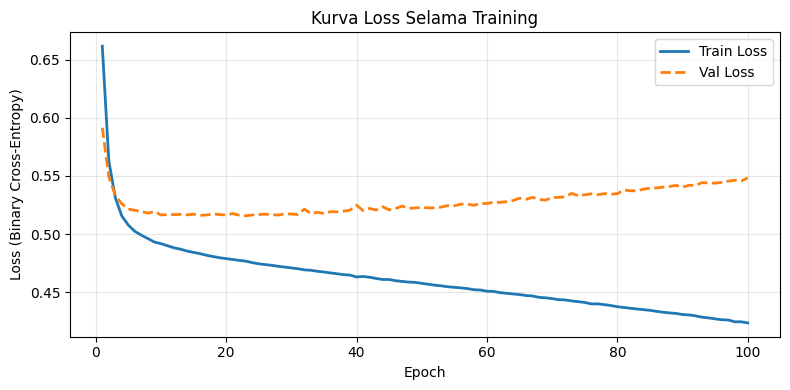

In [10]:
# Kurva loss training vs validasi
fig, ax = plt.subplots(figsize=(8, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

ax.plot(epochs_range, history["train_loss"], label="Train Loss", linewidth=2)
ax.plot(epochs_range, history["val_loss"],   label="Val Loss",   linewidth=2, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (Binary Cross-Entropy)")
ax.set_title("Kurva Loss Selama Training")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


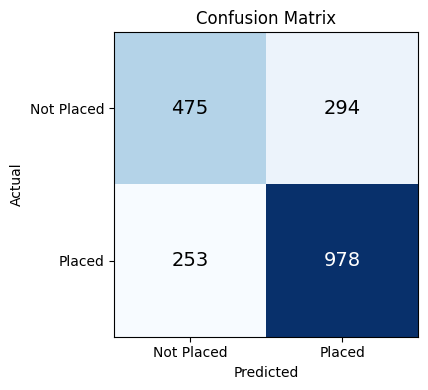


Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.65      0.62      0.63       769
      Placed       0.77      0.79      0.78      1231

    accuracy                           0.73      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.72      0.73      0.72      2000



In [11]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(X_test)   
y_pred_cls  = (y_pred_prob > 0.5).astype(int).flatten()
y_true_cls  = y_test.flatten().astype(int)

cm = confusion_matrix(y_true_cls, y_pred_cls)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Not Placed", "Placed"])
ax.set_yticklabels(["Not Placed", "Placed"])
ax.set_xlabel("Predicted");  ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true_cls, y_pred_cls,
                             target_names=["Not Placed", "Placed"]))

## 6. Visualisasi Distribusi Bobot & Gradien

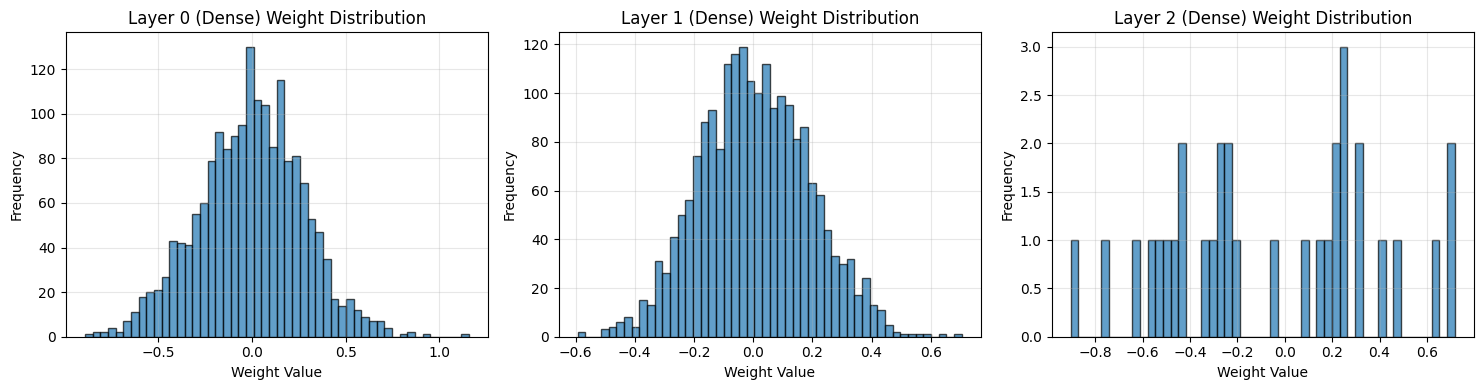

In [12]:
# Distribusi bobot semua layer
model.plot_weight_distributions()

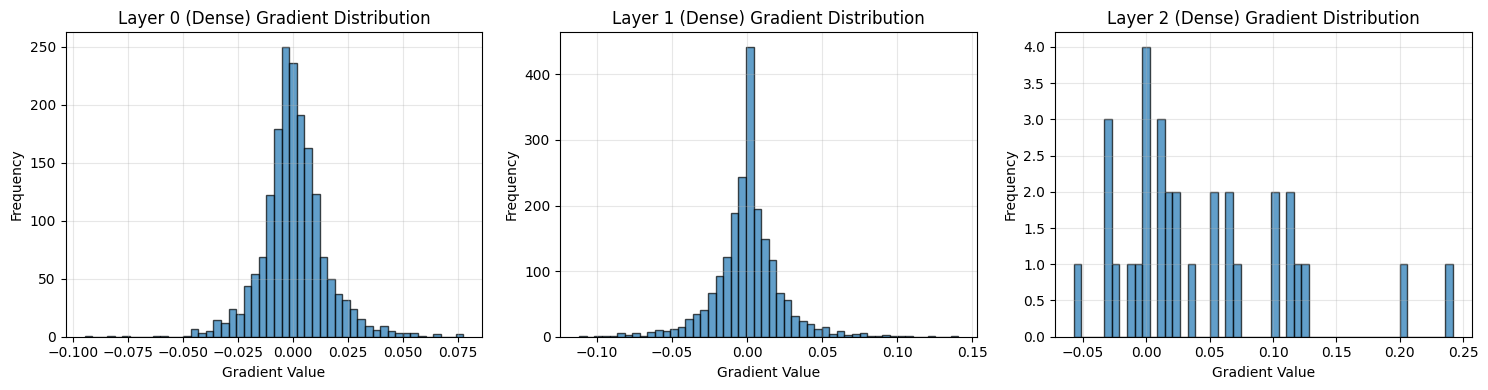

In [13]:
# Hitung gradien satu mini-batch, lalu tampilkan distribusi
_ = model.forward(X_train[:32])
model.backward(_, y_train[:32])
model.plot_gradient_distributions()


## 7. Eksperimen Perbandingan Arsitektur

Perbandingan tiga arsitektur berbeda:
| Nama | Arsitektur |
|------|-----------|
| Kecil | 32 → 1 |
| Sedang | 64 → 32 → 1 |
| Besar | 128 → 64 → 32 → 1 |

In [14]:
def build_model(layer_sizes: list, lr: float = 0.01) -> Model:
    """Buat model biner dengan hidden layers sesuai layer_sizes."""
    m = Model()
    for units in layer_sizes:
        m.add(Dense(units=units, activation="relu", init="he"))
    m.add(Dense(units=1, activation="sigmoid", init="xavier"))
    m.compile(loss="binary_crossentropy", learning_rate=lr)
    return m

ARCHITECTURES = {
    "Kecil  (32→1)":       [32],
    "Sedang (64→32→1)":     [64, 32],
    "Besar  (128→64→32→1)": [128, 64, 32],
}

FIT_KWARGS = dict(
    epochs=50, batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0, shuffle=True
)

results = {}
for name, sizes in ARCHITECTURES.items():
    print(f"Training: {name} ...", end=" ", flush=True)
    m = build_model(sizes)
    hist = m.fit(X_train, y_train, **FIT_KWARGS)
    _, acc = m.evaluate(X_test, y_test)
    results[name] = {"history": hist, "acc": acc}
    print(f"test acc = {acc:.4f}")


Training: Kecil  (32→1) ... test acc = 0.7505
Training: Sedang (64→32→1) ... test acc = 0.7415
Training: Besar  (128→64→32→1) ... test acc = 0.7305


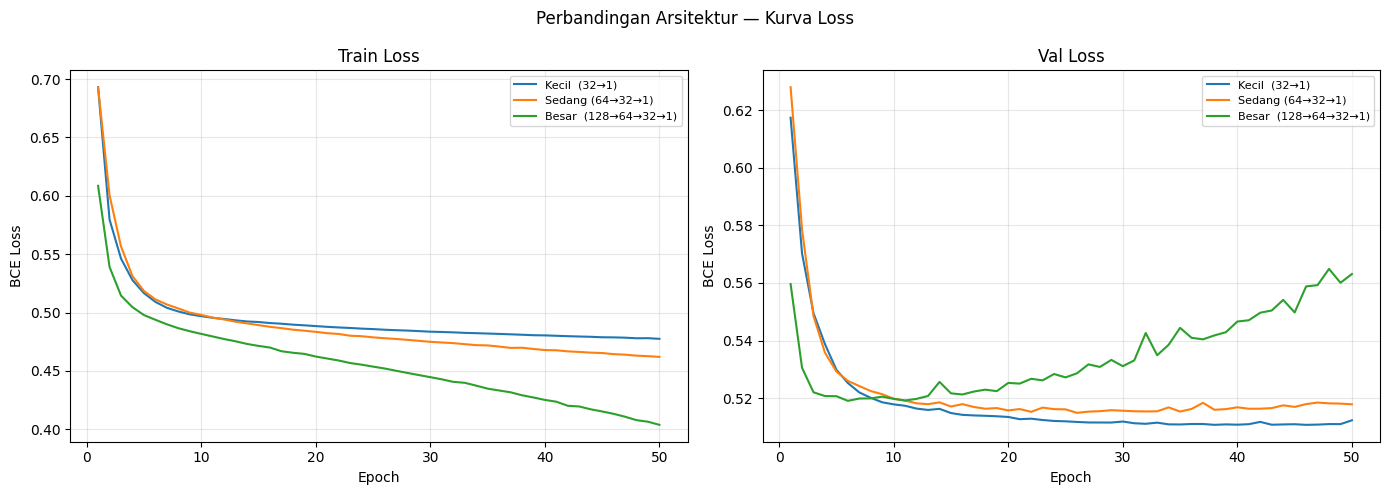


Arsitektur                     Test Acc
---------------------------------------------
Kecil  (32→1)                    0.7505
Sedang (64→32→1)                 0.7415
Besar  (128→64→32→1)             0.7305


In [15]:
# Plot perbandingan kurva loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in results.items():
    h = res["history"]
    ep = range(1, len(h["train_loss"]) + 1)
    axes[0].plot(ep, h["train_loss"], label=name)
    axes[1].plot(ep, h["val_loss"],   label=name)

axes[0].set_title("Train Loss"); axes[0].set_xlabel("Epoch"); axes[0].grid(True, alpha=0.3)
axes[1].set_title("Val Loss");   axes[1].set_xlabel("Epoch"); axes[1].grid(True, alpha=0.3)
for ax in axes:
    ax.set_ylabel("BCE Loss")
    ax.legend(fontsize=8)

plt.suptitle("Perbandingan Arsitektur — Kurva Loss", fontsize=12)
plt.tight_layout()
plt.show()

# Tabel hasil akhir
print("\n" + "="*45)
print(f"{'Arsitektur':<28} {'Test Acc':>10}")
print("-"*45)
for name, res in results.items():
    print(f"{name:<28} {res['acc']:>10.4f}")
print("="*45)

## 8. Simpan & Load Model

Model disimpan ke file JSON dan diload kembali menggunakan `model.save()` / `model.load()`.

In [16]:
SAVE_PATH = "saved_ffnn_model.json"

model.save(SAVE_PATH)

loaded_model = Model()
loaded_model.load(SAVE_PATH)

_, acc_loaded = loaded_model.evaluate(X_test, y_test)
print(f"Accuracy model asli  : {test_acc:.4f}")
print(f"Accuracy model yang diload: {acc_loaded:.4f}")
assert abs(acc_loaded - test_acc) < 1e-6, "Accuracy berbeda"
print("Model berhasil disimpan dan diload kembali.")


Model saved to saved_ffnn_model.json
Model loaded from saved_ffnn_model.json
Accuracy model asli  : 0.7265
Accuracy model yang diload: 0.7265
Model berhasil disimpan dan diload kembali.


## 9. Prediksi pada Sampel Baru


In [17]:
# Prediksi 5 sampel acak dari test set
sample_indices = np.random.default_rng(0).choice(len(X_test), size=5, replace=False)
X_sample = X_test[sample_indices]
y_sample = y_test[sample_indices].flatten().astype(int)

probs  = model.predict(X_sample).flatten()
preds  = (probs > 0.5).astype(int)
labels = {0: "Not Placed", 1: "Placed"}

print(f"{'#':>3}  {'P(Placed)':>10}  {'Prediksi':>12}  {'Aktual':>12}  {'Benar?':>7}")
print("-" * 55)
for i, (p, pred, actual) in enumerate(zip(probs, preds, y_sample)):
    status = "Ya" if pred == actual else "Tidak"
    print(f"{i+1:>3}  {p:>10.4f}  {labels[pred]:>12}  {labels[actual]:>12}  {status:>7}")


  #   P(Placed)      Prediksi        Aktual   Benar?
-------------------------------------------------------
  1      0.3759    Not Placed    Not Placed       Ya
  2      0.9452        Placed        Placed       Ya
  3      0.2406    Not Placed        Placed    Tidak
  4      0.0315    Not Placed    Not Placed       Ya
  5      0.3673    Not Placed    Not Placed       Ya


## 10. Pengaruh Depth & Width

### Variasi Width (jumlah neuron)

| Nama | Arsitektur |
|------|-----------|
| Sempit | 16 → 16 → 1 |
| Sedang | 64 → 64 → 1 |
| Lebar  | 256 → 256 → 1 |

### Variasi Depth (hidden layer)

| Nama | Arsitektur |
|------|-----------|
| Dangkal (1 hidden) | 64 → 1 |
| Sedang  (2 hidden) | 64 → 64 → 1 |
| Dalam   (3 hidden) | 64 → 64 → 64 → 1 |


In [18]:
# Variasi Width
WIDTH_CONFIGS = {
    "Sempit (16×2→1)":  [16, 16],
    "Sedang (64×2→1)":  [64, 64],
    "Lebar  (256×2→1)": [256, 256],
}

width_results = {}
for name, sizes in WIDTH_CONFIGS.items():
    print(f"Training {name} ...", end=" ", flush=True)
    m = build_model(sizes)
    hist = m.fit(X_train, y_train, **FIT_KWARGS)
    _, acc = m.evaluate(X_test, y_test)
    width_results[name] = {"history": hist, "acc": acc, "model": m}
    print(f"test acc = {acc:.4f}")

print()

# Variasi Depth
DEPTH_CONFIGS = {
    "Dangkal (64×1→1)": [64],
    "Sedang  (64×2→1)": [64, 64],
    "Dalam   (64×3→1)": [64, 64, 64],
}

depth_results = {}
for name, sizes in DEPTH_CONFIGS.items():
    print(f"Training {name} ...", end=" ", flush=True)
    m = build_model(sizes)
    hist = m.fit(X_train, y_train, **FIT_KWARGS)
    _, acc = m.evaluate(X_test, y_test)
    depth_results[name] = {"history": hist, "acc": acc, "model": m}
    print(f"test acc = {acc:.4f}")


Training Sempit (16×2→1) ... test acc = 0.7495
Training Sedang (64×2→1) ... test acc = 0.7410
Training Lebar  (256×2→1) ... test acc = 0.7330

Training Dangkal (64×1→1) ... test acc = 0.7465
Training Sedang  (64×2→1) ... test acc = 0.7320
Training Dalam   (64×3→1) ... test acc = 0.7325


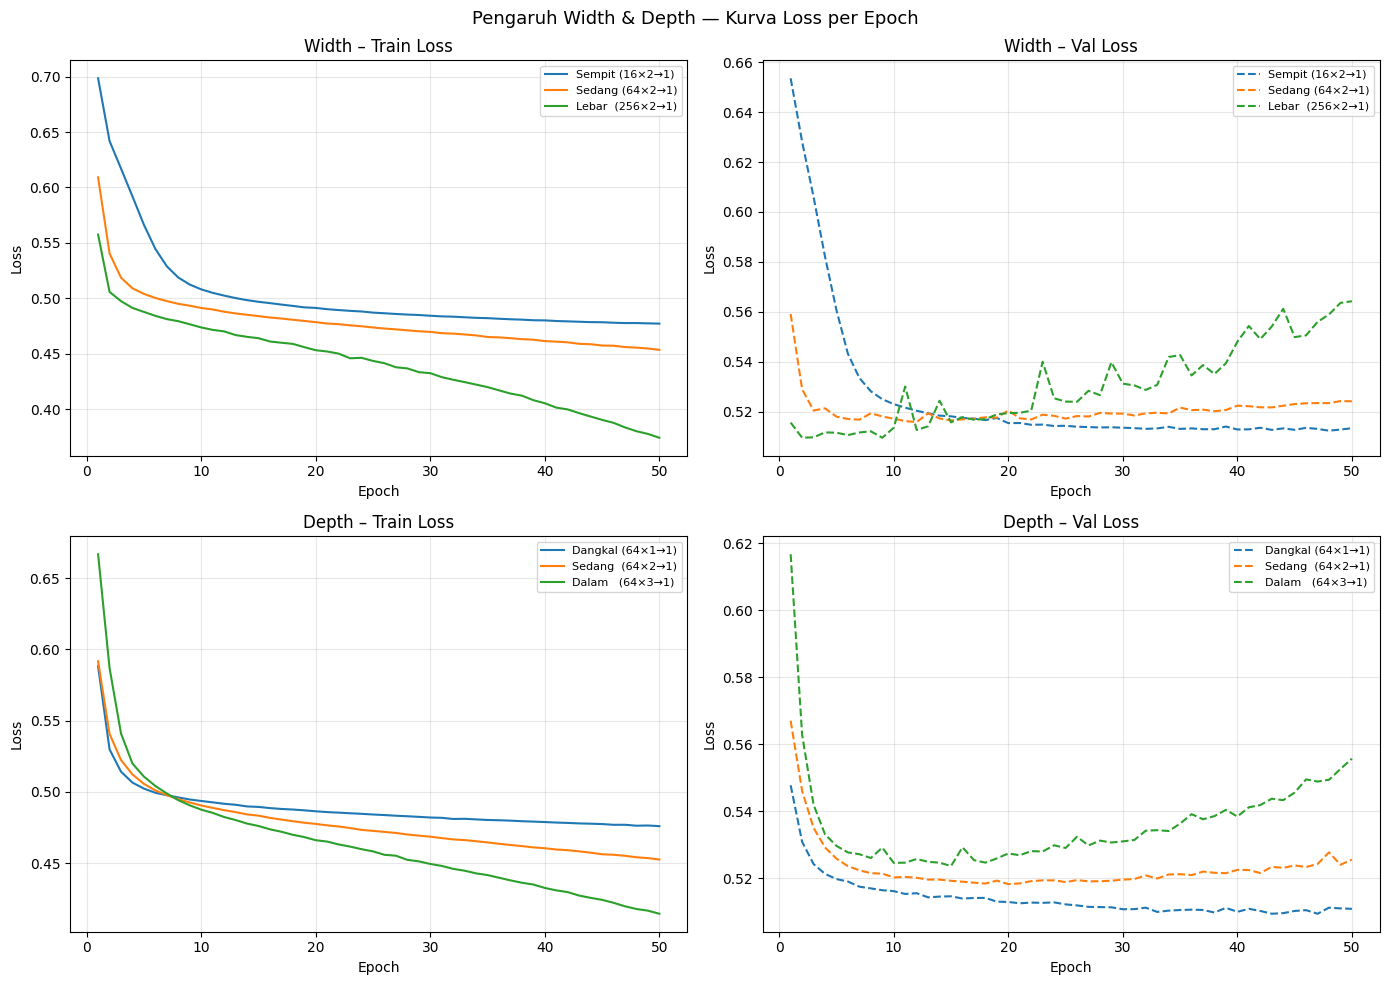


── Variasi Width (depth=2 hidden layers) ──
Arsitektur               Test Acc
-----------------------------------
Sempit (16×2→1)            0.7495  (74.95%)
Sedang (64×2→1)            0.7410  (74.10%)
Lebar  (256×2→1)           0.7330  (73.30%)

── Variasi Depth (width=64 per layer) ──
Arsitektur                 Test Acc
-------------------------------------
Dangkal (64×1→1)             0.7465  (74.65%)
Sedang  (64×2→1)             0.7320  (73.20%)
Dalam   (64×3→1)             0.7325  (73.25%)


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Width train loss
for name, res in width_results.items():
    ep = range(1, len(res["history"]["train_loss"]) + 1)
    axes[0, 0].plot(ep, res["history"]["train_loss"], label=name)
axes[0, 0].set_title("Width – Train Loss")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend(fontsize=8); axes[0, 0].grid(True, alpha=0.3)

# Width val loss
for name, res in width_results.items():
    ep = range(1, len(res["history"]["val_loss"]) + 1)
    axes[0, 1].plot(ep, res["history"]["val_loss"], label=name, linestyle="--")
axes[0, 1].set_title("Width – Val Loss")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend(fontsize=8); axes[0, 1].grid(True, alpha=0.3)

# Depth train loss
for name, res in depth_results.items():
    ep = range(1, len(res["history"]["train_loss"]) + 1)
    axes[1, 0].plot(ep, res["history"]["train_loss"], label=name)
axes[1, 0].set_title("Depth – Train Loss")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend(fontsize=8); axes[1, 0].grid(True, alpha=0.3)

# Depth val loss
for name, res in depth_results.items():
    ep = range(1, len(res["history"]["val_loss"]) + 1)
    axes[1, 1].plot(ep, res["history"]["val_loss"], label=name, linestyle="--")
axes[1, 1].set_title("Depth – Val Loss")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend(fontsize=8); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Pengaruh Width & Depth — Kurva Loss per Epoch", fontsize=13)
plt.tight_layout()
plt.show()

# Tabel perbandingan prediksi akhir
print("\n── Variasi Width (depth=2 hidden layers) ──")
print(f"{'Arsitektur':<22} {'Test Acc':>10}")
print("-" * 35)
for name, res in width_results.items():
    print(f"{name:<22} {res['acc']:>10.4f}  ({res['acc']*100:.2f}%)")

print("\n── Variasi Depth (width=64 per layer) ──")
print(f"{'Arsitektur':<24} {'Test Acc':>10}")
print("-" * 37)
for name, res in depth_results.items():
    print(f"{name:<24} {res['acc']:>10.4f}  ({res['acc']*100:.2f}%)")


## 11. Pengaruh Fungsi Aktivasi Hidden Layer

**Base arsitektur** (4 layer termasuk output):
```
Input → Dense(64, relu) → Dense(64, [*test*]) → Dense(32, relu) → Dense(1, sigmoid)
```

Layer yang diuji/dipilih adalah **Layer ke-2** (hidden layer kedua, indeks 1).

Fungsi aktivasi yang diuji: `relu`, `sigmoid`, `tanh`, `linear` (kecuali softmax)

Setiap variasi dibandingkan dari sisi:
- Hasil prediksi akhir (test accuracy)
- Kurva training loss & validation loss
- Distribusi bobot & gradien semua layer


In [20]:
def plot_compare_distributions(models_dict, X_batch, y_batch, title="", n_layers=3):
    """Plot distribusi bobot dan gradien beberapa model secara berdampingan.

    Parameters
    ----------
    models_dict : dict {label: Model}
    X_batch, y_batch : array — mini-batch untuk menghitung gradien
    n_layers : int — jumlah layer pertama yang ditampilkan
    """
    names = list(models_dict.keys())
    n     = len(names)
    cols  = n_layers * 2

    fig, axes = plt.subplots(n, cols, figsize=(4 * cols, 3 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    colors_w = ["steelblue", "seagreen", "darkorange", "mediumpurple"]
    colors_g = ["tomato",    "coral",    "salmon",     "lightcoral"]

    for row, name in enumerate(names):
        m = models_dict[name]
        out = m.forward(X_batch)
        m.backward(out, y_batch)

        for li in range(n_layers):
            if li >= len(m.layers):
                axes[row, li].axis("off")
                axes[row, n_layers + li].axis("off")
                continue
            layer = m.layers[li]

            ax_w = axes[row, li]
            if hasattr(layer, "W") and layer.W is not None:
                ax_w.hist(layer.W.flatten(), bins=40, alpha=0.75,
                          color=colors_w[row % len(colors_w)], edgecolor="white")
            ax_w.set_title(f"{name}\nLayer {li} — Bobot", fontsize=8)
            ax_w.set_xlabel("Nilai", fontsize=7)
            ax_w.grid(True, alpha=0.3)

            ax_g = axes[row, n_layers + li]
            if hasattr(layer, "_dW") and layer._dW is not None:
                ax_g.hist(layer._dW.flatten(), bins=40, alpha=0.75,
                          color=colors_g[row % len(colors_g)], edgecolor="white")
            ax_g.set_title(f"{name}\nLayer {li} — Gradien Bobot", fontsize=8)
            ax_g.set_xlabel("Nilai", fontsize=7)
            ax_g.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


In [21]:
ACTIVATIONS_TEST = ["relu", "sigmoid", "tanh", "linear"]

act_results = {}
act_models  = {}

for act in ACTIVATIONS_TEST:
    print(f"Training aktivasi='{act}' pada layer ke-2 ...", end=" ", flush=True)
    m = Model()
    m.add(Dense(units=64, activation="relu",    init="he"))
    m.add(Dense(units=64, activation=act,       init="auto"))
    m.add(Dense(units=32, activation="relu",    init="he"))
    m.add(Dense(units=1,  activation="sigmoid", init="xavier"))
    m.compile(loss="binary_crossentropy", learning_rate=0.01)
    hist = m.fit(X_train, y_train, **FIT_KWARGS)
    _, acc = m.evaluate(X_test, y_test)
    act_results[act] = {"history": hist, "acc": acc}
    act_models[act]  = m
    print(f"test acc = {acc:.4f}")


Training aktivasi='relu' pada layer ke-2 ... test acc = 0.7360
Training aktivasi='sigmoid' pada layer ke-2 ... test acc = 0.7515
Training aktivasi='tanh' pada layer ke-2 ... test acc = 0.7410
Training aktivasi='linear' pada layer ke-2 ... test acc = 0.7345


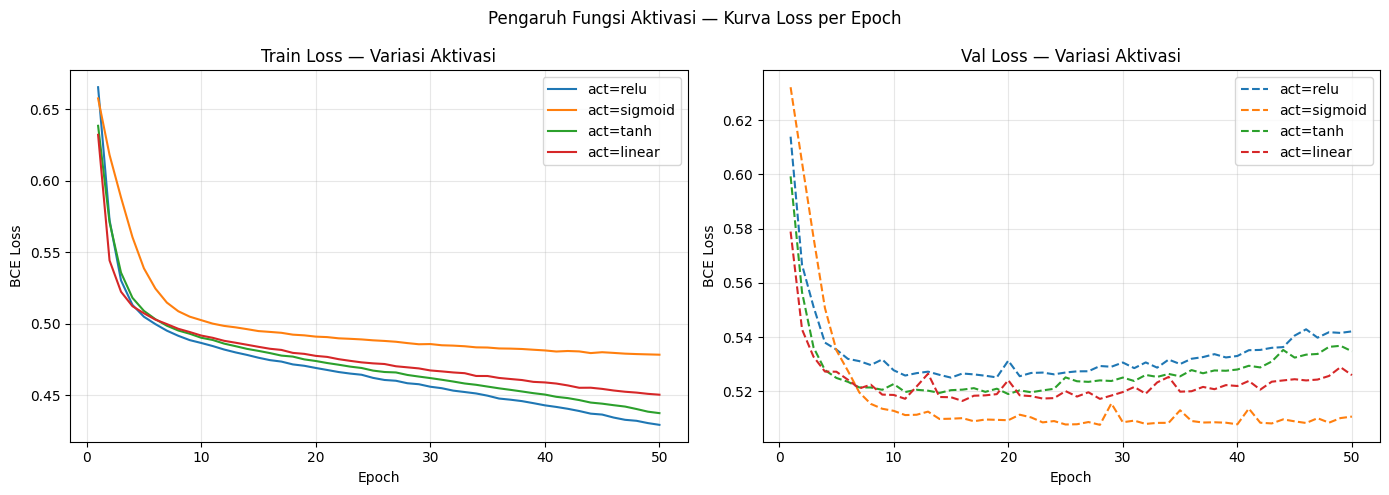


Aktivasi Layer-2     Test Acc
-------------------------------
relu                   0.7360  (73.60%)
sigmoid                0.7515  (75.15%)
tanh                   0.7410  (74.10%)
linear                 0.7345  (73.45%)


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for act, res in act_results.items():
    ep = range(1, len(res["history"]["train_loss"]) + 1)
    axes[0].plot(ep, res["history"]["train_loss"], label=f"act={act}")
    axes[1].plot(ep, res["history"]["val_loss"],   label=f"act={act}", linestyle="--")

axes[0].set_title("Train Loss — Variasi Aktivasi")
axes[1].set_title("Val Loss — Variasi Aktivasi")
for ax in axes:
    ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Pengaruh Fungsi Aktivasi — Kurva Loss per Epoch", fontsize=12)
plt.tight_layout()
plt.show()

# Tabel prediksi akhir
print(f"\n{'Aktivasi Layer-2':<18} {'Test Acc':>10}")
print("-" * 31)
for act, res in act_results.items():
    print(f"{act:<18} {res['acc']:>10.4f}  ({res['acc']*100:.2f}%)")


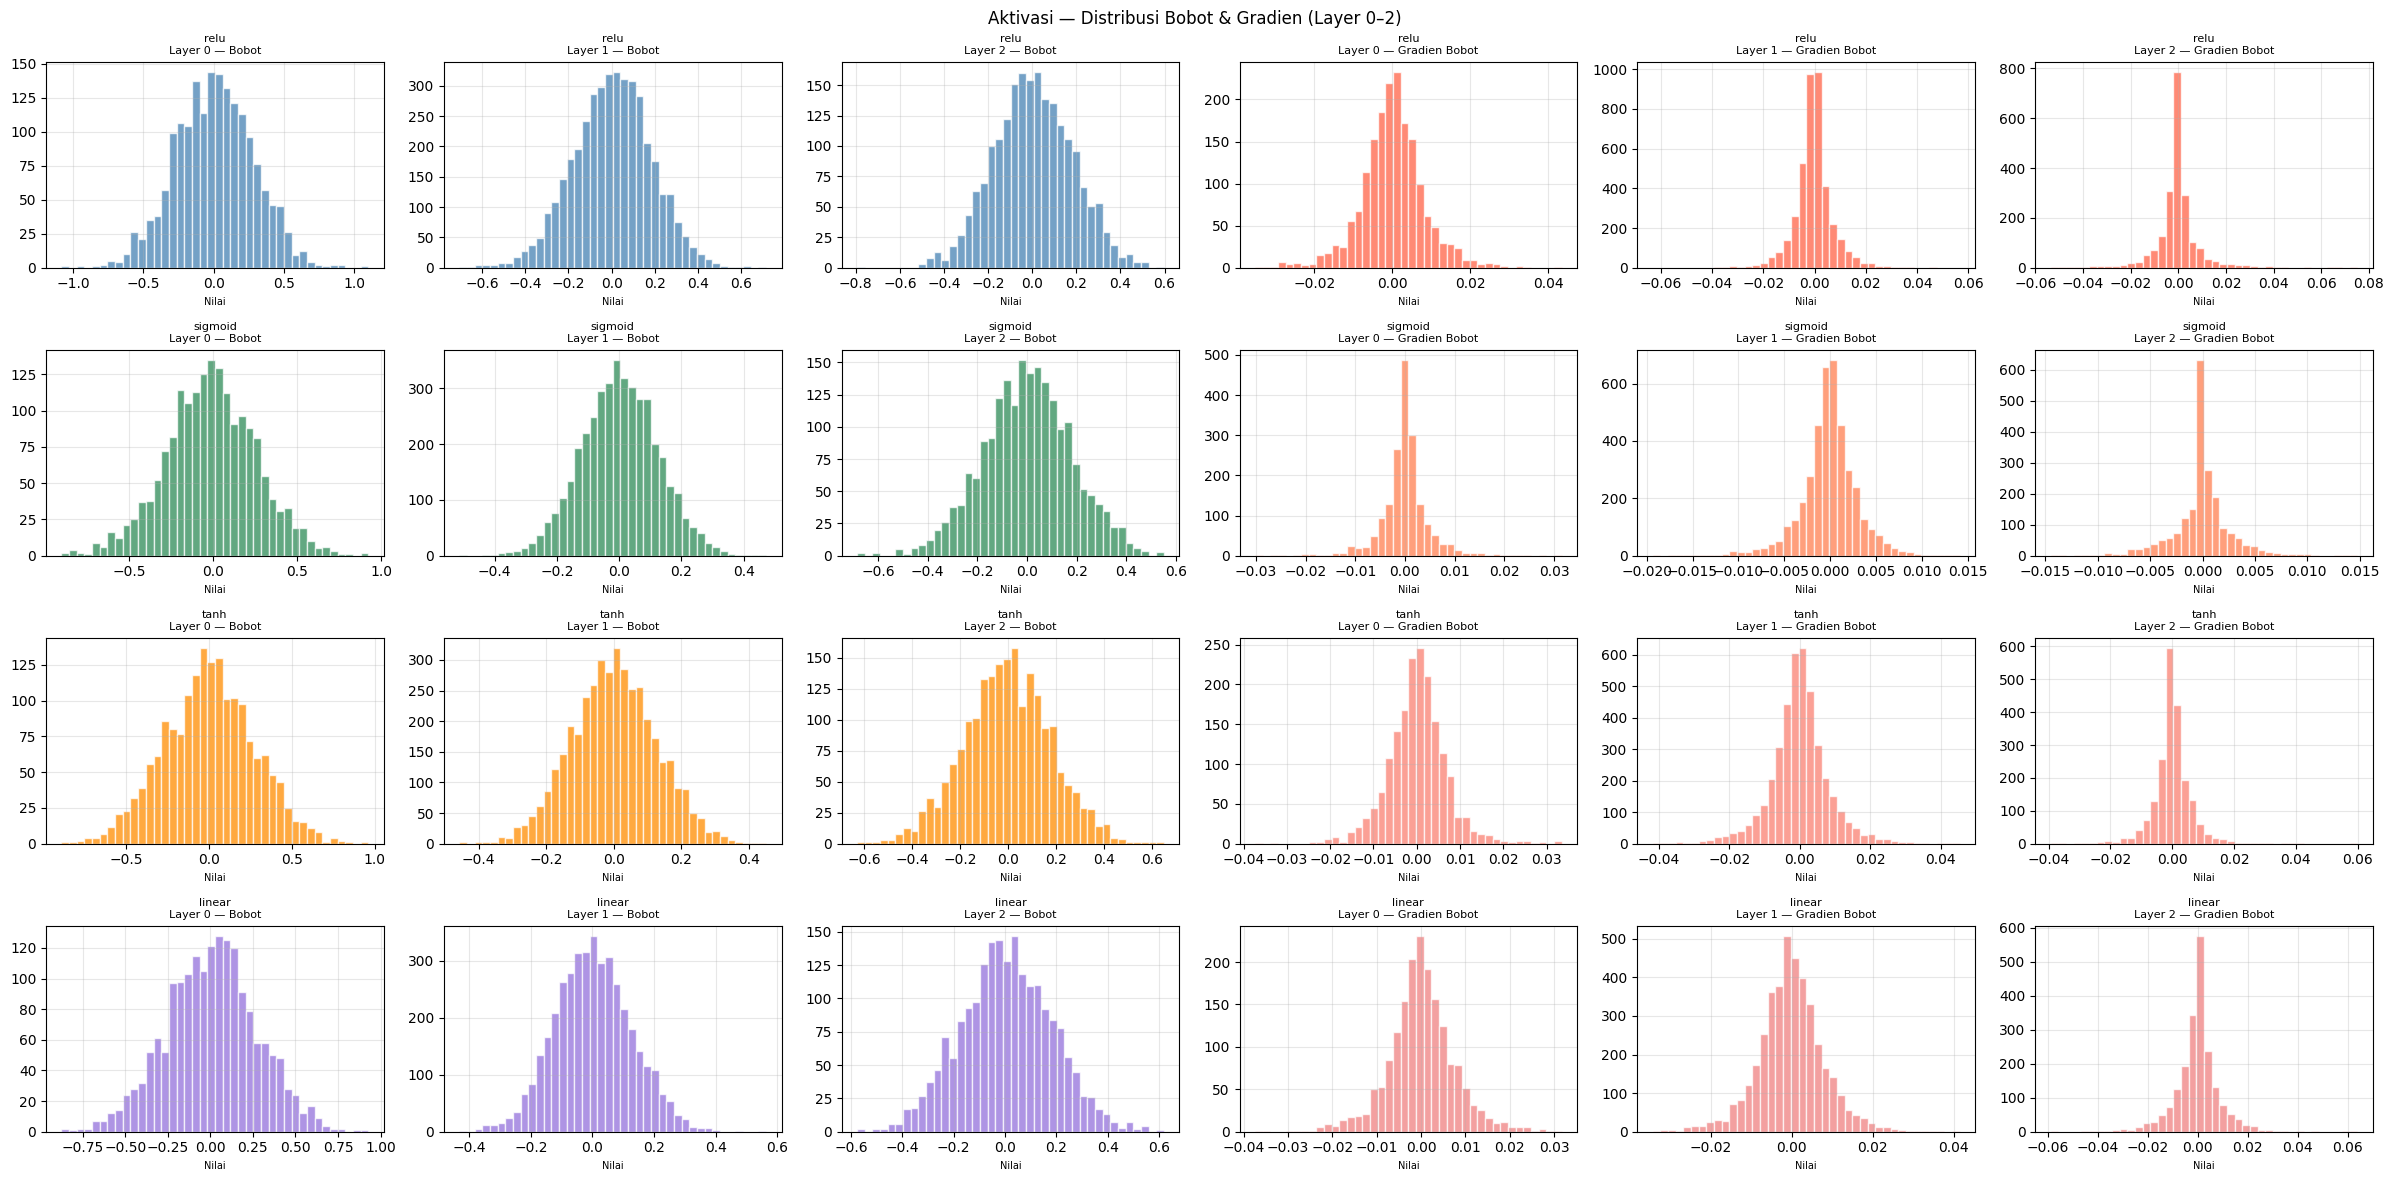

In [23]:
# Bandingkan distribusi bobot & gradien untuk semua 4 layer dari tiap model aktivasi
# hanya menggunakan 64 sampel train (mini batch)
plot_compare_distributions(
    act_models,
    X_train[:64], y_train[:64],
    title="Aktivasi — Distribusi Bobot & Gradien (Layer 0–2)",
    n_layers=3,
)


## 12. Pengaruh Learning Rate

**Arsitektur tetap:**
```
Dense(64, relu) → Dense(32, relu) → Dense(1, sigmoid)
```
Loss: Binary Cross-Entropy  
Optimizer: SGD  
Epochs: 50  
Batch: 32  

| Learning Rate | Keterangan |
|:---:|---|
| 0.001 | sangat kecil |
| 0.01  | Default |
| 0.1   | Besar |

Perbandingan: hasil prediksi akhir, kurva loss, dan distribusi bobot & gradien.


In [24]:
LR_CONFIGS = [0.001, 0.01, 0.1]

lr_results = {}
lr_models  = {}

for lr in LR_CONFIGS:
    label = f"lr={lr}"
    print(f"Training {label} ...", end=" ", flush=True)
    m = Model()
    m.add(Dense(units=64, activation="relu",    init="he"))
    m.add(Dense(units=32, activation="relu",    init="he"))
    m.add(Dense(units=1,  activation="sigmoid", init="xavier"))
    m.compile(loss="binary_crossentropy", learning_rate=lr)
    hist = m.fit(X_train, y_train, epochs=50, batch_size=32,
                 validation_data=(X_test, y_test), verbose=0, shuffle=True)
    _, acc = m.evaluate(X_test, y_test)
    lr_results[label] = {"history": hist, "acc": acc}
    lr_models[label]  = m
    print(f"test acc = {acc:.4f}")


Training lr=0.001 ... test acc = 0.7325
Training lr=0.01 ... test acc = 0.7400
Training lr=0.1 ... test acc = 0.6900


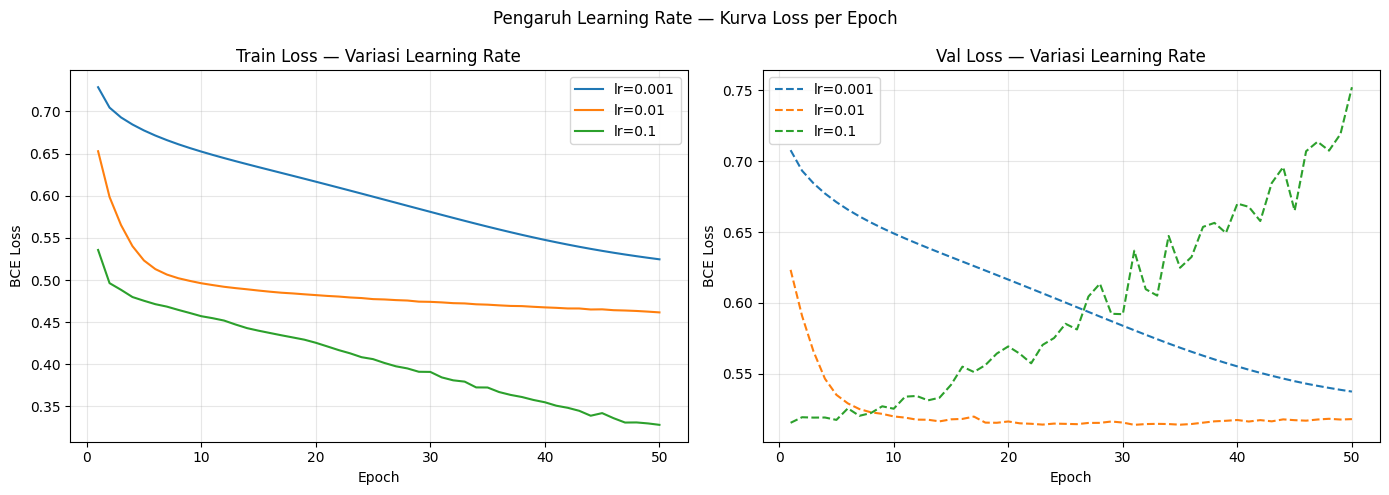


Learning Rate     Test Acc
----------------------------
lr=0.001            0.7325  (73.25%)
lr=0.01             0.7400  (74.00%)
lr=0.1              0.6900  (69.00%)


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in lr_results.items():
    ep = range(1, len(res["history"]["train_loss"]) + 1)
    axes[0].plot(ep, res["history"]["train_loss"], label=name)
    axes[1].plot(ep, res["history"]["val_loss"],   label=name, linestyle="--")

axes[0].set_title("Train Loss — Variasi Learning Rate")
axes[1].set_title("Val Loss — Variasi Learning Rate")
for ax in axes:
    ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Pengaruh Learning Rate — Kurva Loss per Epoch", fontsize=12)
plt.tight_layout()
plt.show()

# Tabel prediksi akhir
print(f"\n{'Learning Rate':<15} {'Test Acc':>10}")
print("-" * 28)
for name, res in lr_results.items():
    print(f"{name:<15} {res['acc']:>10.4f}  ({res['acc']*100:.2f}%)")


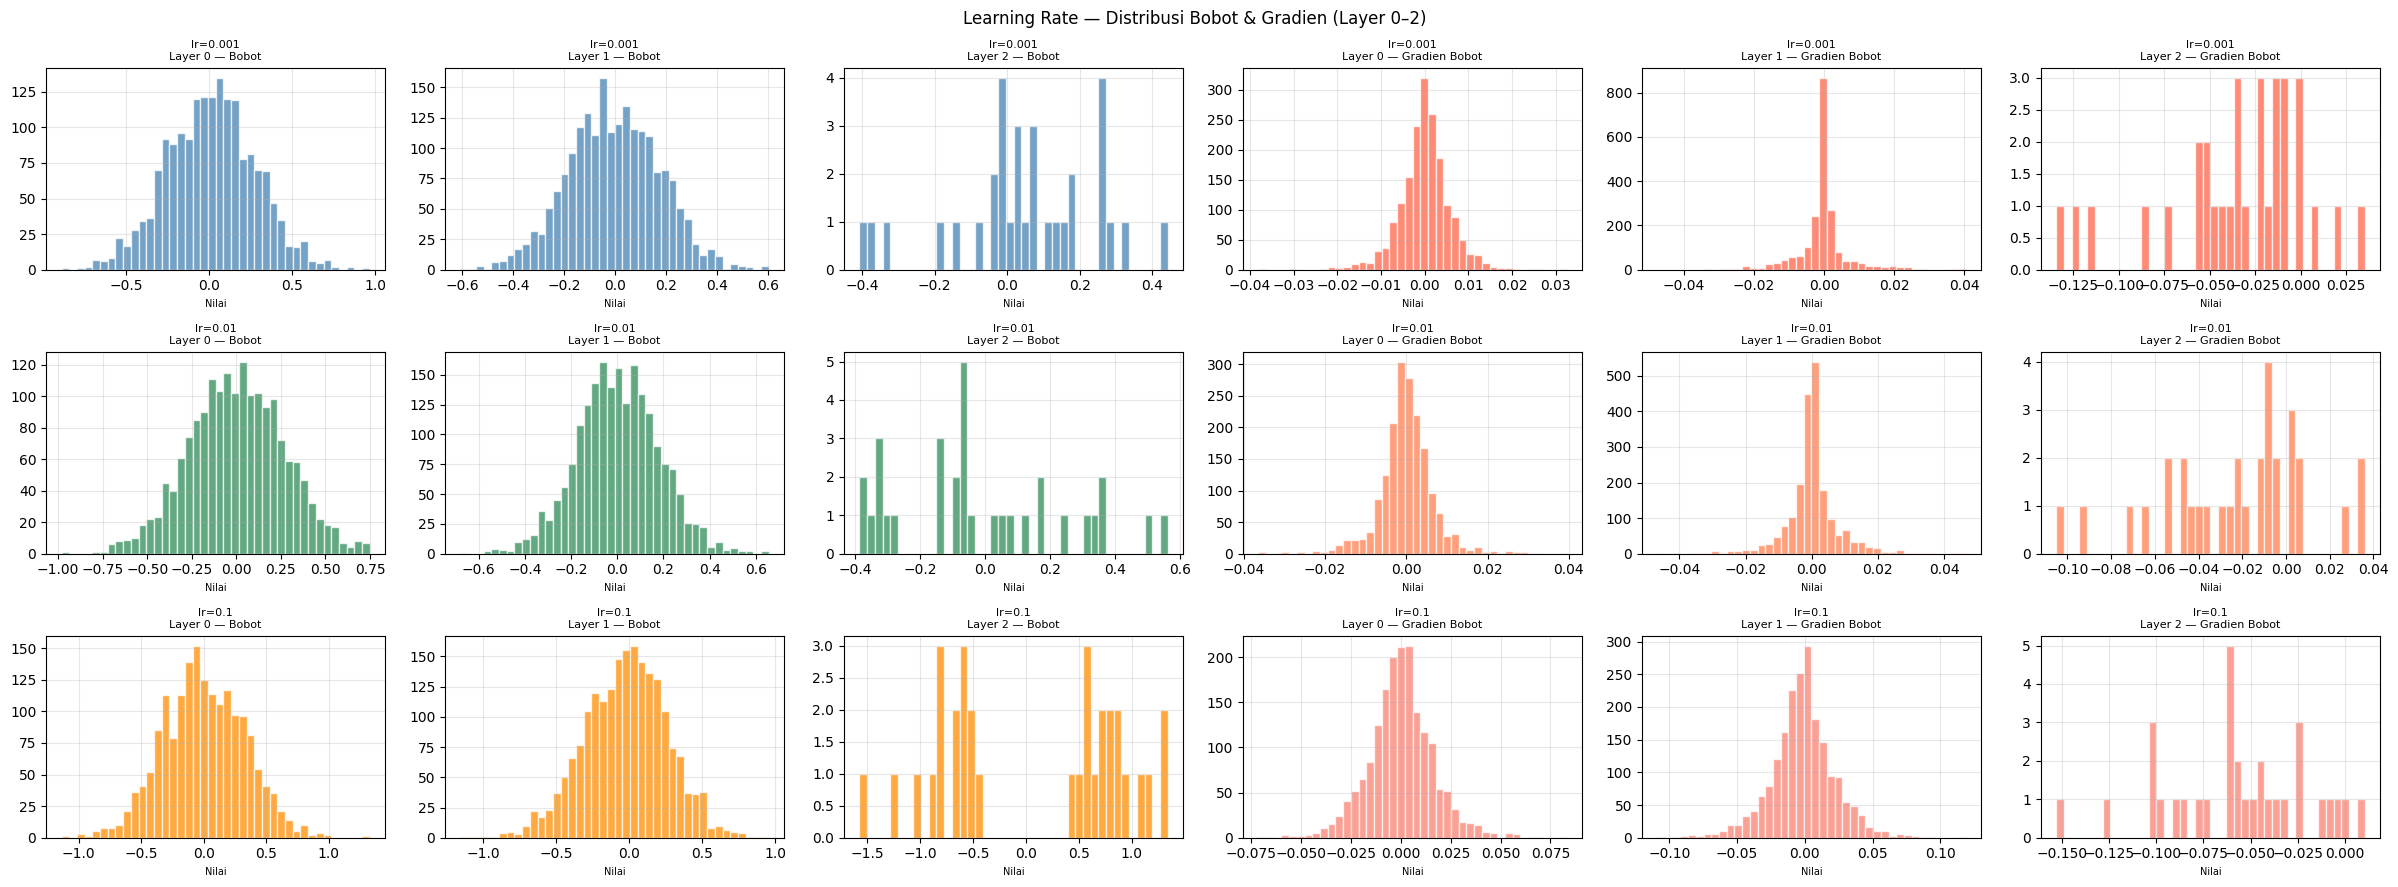

In [26]:
plot_compare_distributions(
    lr_models,
    X_train[:64], y_train[:64],
    title="Learning Rate — Distribusi Bobot & Gradien (Layer 0–2)",
    n_layers=3,
)


## 13. Pengaruh Regularisasi

**Arsitektur tetap:**
```
Dense(64, relu) → Dense(32, relu) → Dense(1, sigmoid)
```
Regularisasi diterapkan pada kedua hidden layer.  
Learning rate: 0.01  
Epochs: 50  
Batch: 32

| Konfigurasi | L1 (λ) | L2 (λ) |
|-------------|:------:|:------:|
| Tanpa regularisasi | 0.0 | 0.0 |
| L1 Regularisasi (Lasso) | 0.001 | 0.0 |
| L2 Regularisasi (Ridge) | 0.0 | 0.001 |

Perbandingan: hasil prediksi akhir, kurva loss, dan distribusi bobot & gradien.


In [27]:
REG_CONFIGS = {
    "Tanpa Reg":     {"l1": 0.0,   "l2": 0.0},
    "L1 (λ=0.001)":  {"l1": 0.001, "l2": 0.0},
    "L2 (λ=0.001)":  {"l1": 0.0,   "l2": 0.001},
}

reg_results = {}
reg_models  = {}

for name, reg_params in REG_CONFIGS.items():
    print(f"Training {name} ...", end=" ", flush=True)
    m = Model()
    m.add(Dense(units=64, activation="relu",    init="he",     **reg_params))
    m.add(Dense(units=32, activation="relu",    init="he",     **reg_params))
    m.add(Dense(units=1,  activation="sigmoid", init="xavier"))
    m.compile(loss="binary_crossentropy", learning_rate=0.01)
    hist = m.fit(X_train, y_train, **FIT_KWARGS)
    _, acc = m.evaluate(X_test, y_test)
    reg_results[name] = {"history": hist, "acc": acc}
    reg_models[name]  = m
    print(f"test acc = {acc:.4f}")


Training Tanpa Reg ... test acc = 0.7450
Training L1 (λ=0.001) ... test acc = 0.7520
Training L2 (λ=0.001) ... test acc = 0.7420


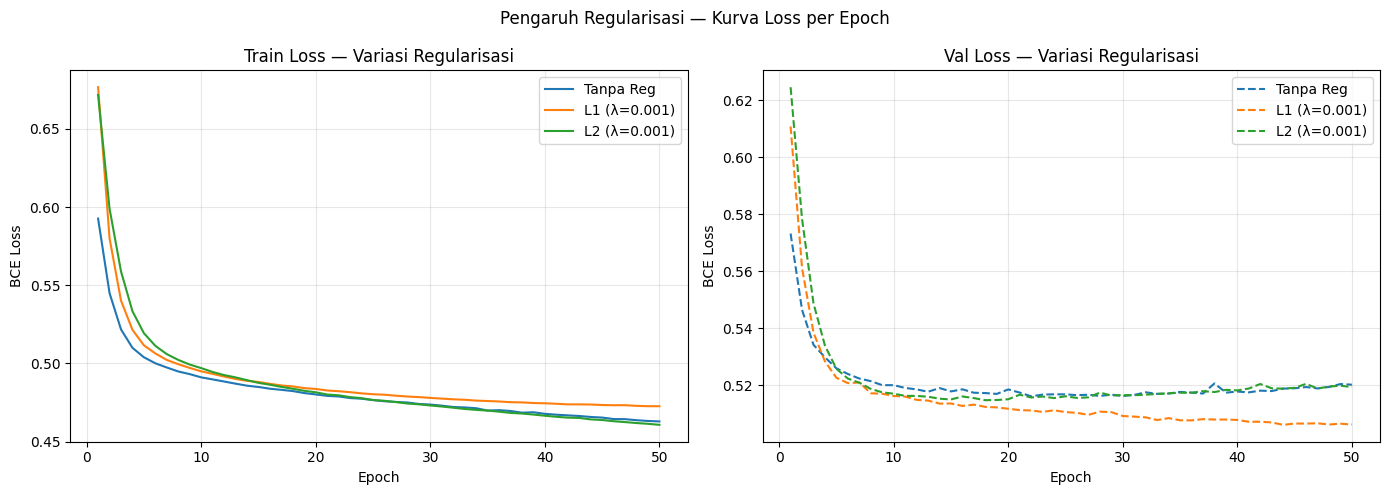


Regularisasi        Test Acc
------------------------------
Tanpa Reg             0.7450  (74.50%)
L1 (λ=0.001)          0.7520  (75.20%)
L2 (λ=0.001)          0.7420  (74.20%)


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in reg_results.items():
    ep = range(1, len(res["history"]["train_loss"]) + 1)
    axes[0].plot(ep, res["history"]["train_loss"], label=name)
    axes[1].plot(ep, res["history"]["val_loss"],   label=name, linestyle="--")

axes[0].set_title("Train Loss — Variasi Regularisasi")
axes[1].set_title("Val Loss — Variasi Regularisasi")
for ax in axes:
    ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Pengaruh Regularisasi — Kurva Loss per Epoch", fontsize=12)
plt.tight_layout()
plt.show()

# Tabel prediksi akhir
print(f"\n{'Regularisasi':<17} {'Test Acc':>10}")
print("-" * 30)
for name, res in reg_results.items():
    print(f"{name:<17} {res['acc']:>10.4f}  ({res['acc']*100:.2f}%)")


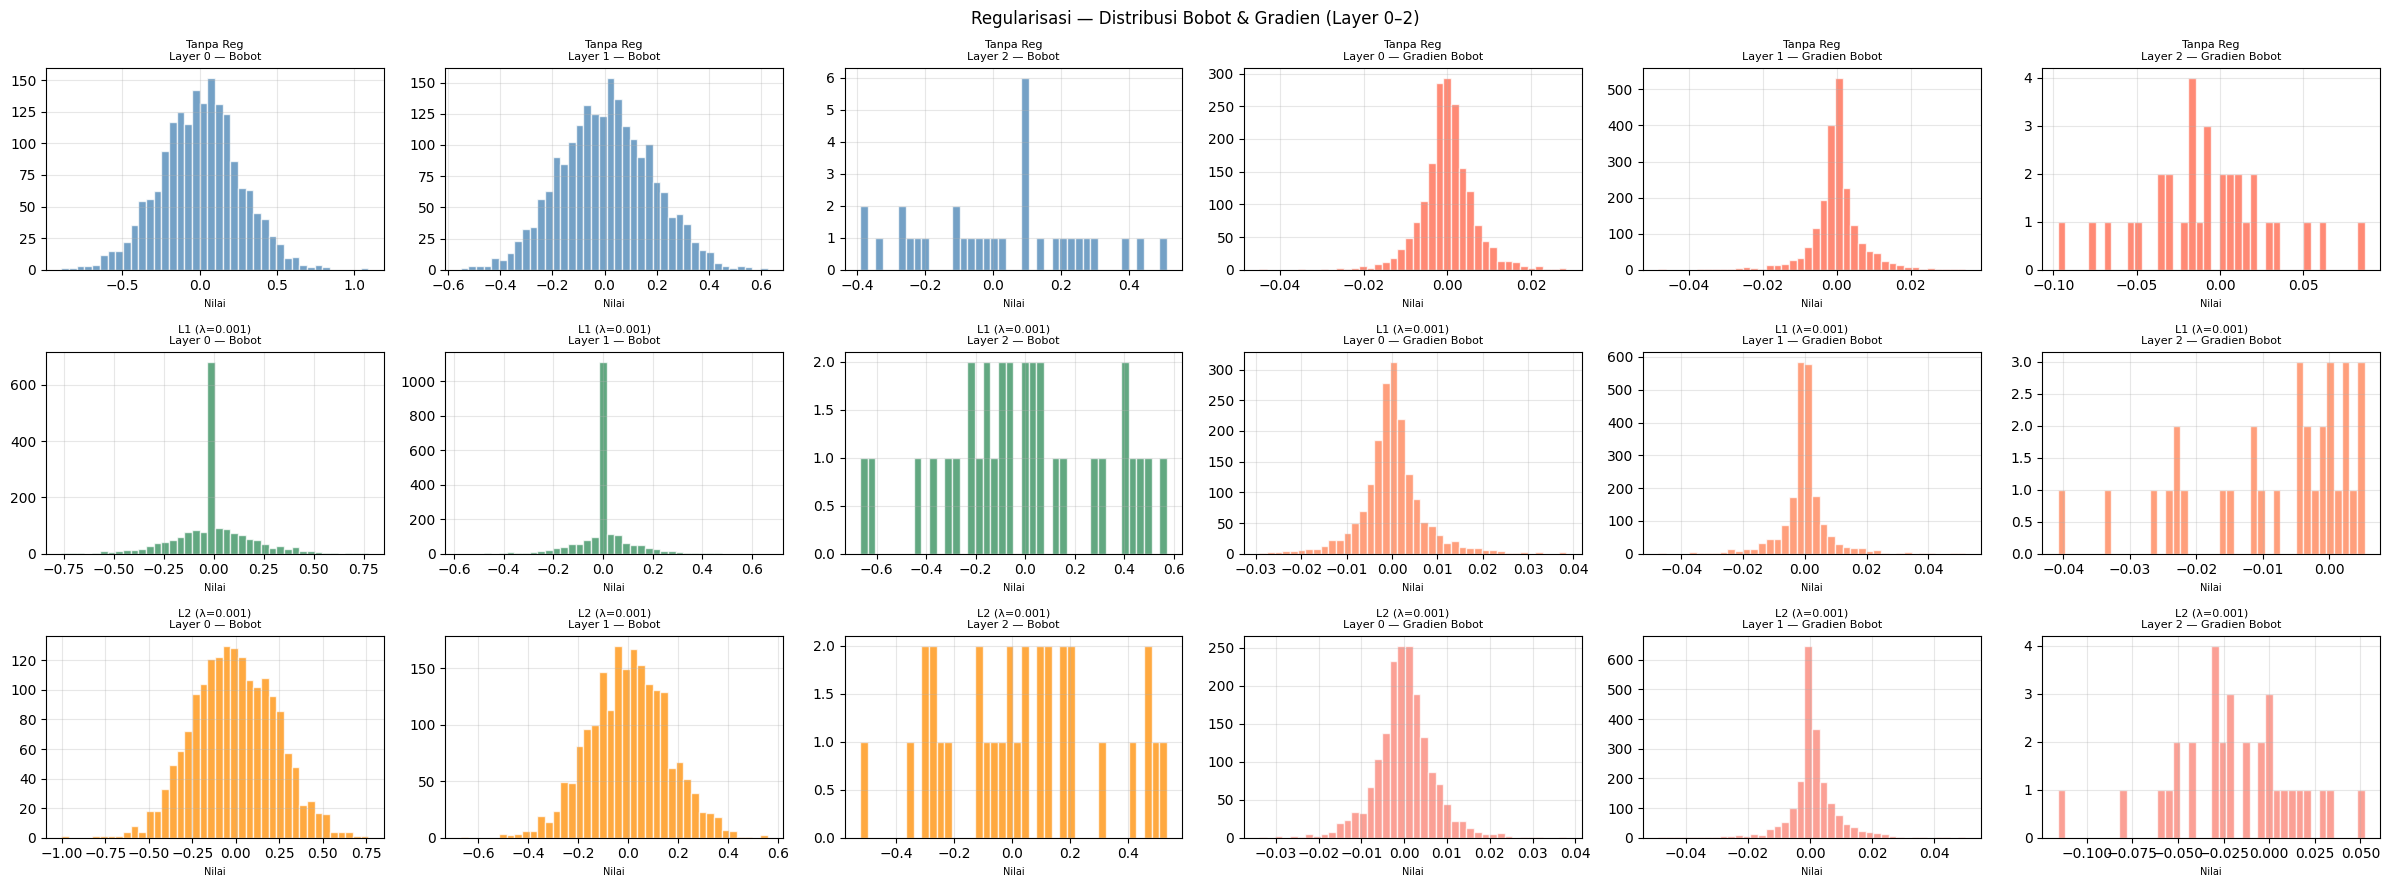

In [29]:
plot_compare_distributions(
    reg_models,
    X_train[:64], y_train[:64],
    title="Regularisasi — Distribusi Bobot & Gradien (Layer 0–2)",
    n_layers=3,
)


## 14. Uji Perbandingan: FFNN buatan vs. sklearn MLP

Satu kali pelatihan menggunakan **hyperparameter yang sama** untuk kedua model:

| Parameter | Nilai |
|-----------|-------|
| Hidden layers | 64 → 32 |
| Aktivasi hidden | ReLU |
| Output | 1 neuron sigmoid / logistic |
| Learning rate | 0.01 |
| Optimizer | SGD |
| Epochs / max_iter | 50 |
| Batch size | 32 |

Hanya **hasil prediksi akhir** (test accuracy) yang dibandingkan.


In [30]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# FFNN Buatan
print("Training FFNN Custom ...", end=" ", flush=True)
m_custom = Model()
m_custom.add(Dense(units=64, activation="relu",    init="he"))
m_custom.add(Dense(units=32, activation="relu",    init="he"))
m_custom.add(Dense(units=1,  activation="sigmoid", init="xavier"))
m_custom.compile(loss="binary_crossentropy", learning_rate=0.01)
m_custom.fit(X_train, y_train, epochs=50, batch_size=32,
             validation_data=(X_test, y_test), verbose=0, shuffle=True)
_, acc_custom = m_custom.evaluate(X_test, y_test)
print(f"done  →  test acc = {acc_custom:.4f}")

# sklearn MLPClassifier dengan hyperparameter yang sama
print("Training sklearn MLP   ...", end=" ", flush=True)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="sgd",
    learning_rate_init=0.01,
    max_iter=50,
    batch_size=32,
    random_state=42,
    shuffle=True,
)
mlp.fit(X_train, y_train.ravel())
acc_sklearn = accuracy_score(y_test.ravel(), mlp.predict(X_test))
print(f"done  →  test acc = {acc_sklearn:.4f}")

# Tabel hasil akhir 
print(f"\n{'Model':<26} {'Test Accuracy':>14}")
print("=" * 42)
print(f"{'FFNN Custom (buatan sendiri)':<26} {acc_custom:>14.4f}  ({acc_custom*100:.2f}%)")
print(f"{'sklearn MLPClassifier':<26} {acc_sklearn:>14.4f}  ({acc_sklearn*100:.2f}%)")
print("=" * 42)
diff = acc_custom - acc_sklearn
sign = "+" if diff >= 0 else ""
print(f"{'Selisih (Custom − sklearn)':<26} {sign}{diff:>14.4f}  ({sign}{diff*100:.2f}%)")


Training FFNN Custom ... done  →  test acc = 0.7365
Training sklearn MLP   ... done  →  test acc = 0.6955

Model                       Test Accuracy
FFNN Custom (buatan sendiri)         0.7365  (73.65%)
sklearn MLPClassifier              0.6955  (69.55%)
Selisih (Custom − sklearn) +        0.0410  (+4.10%)


/Users/alvin/Documents/ITB/sem6/ML/ML-Xianglongbao/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


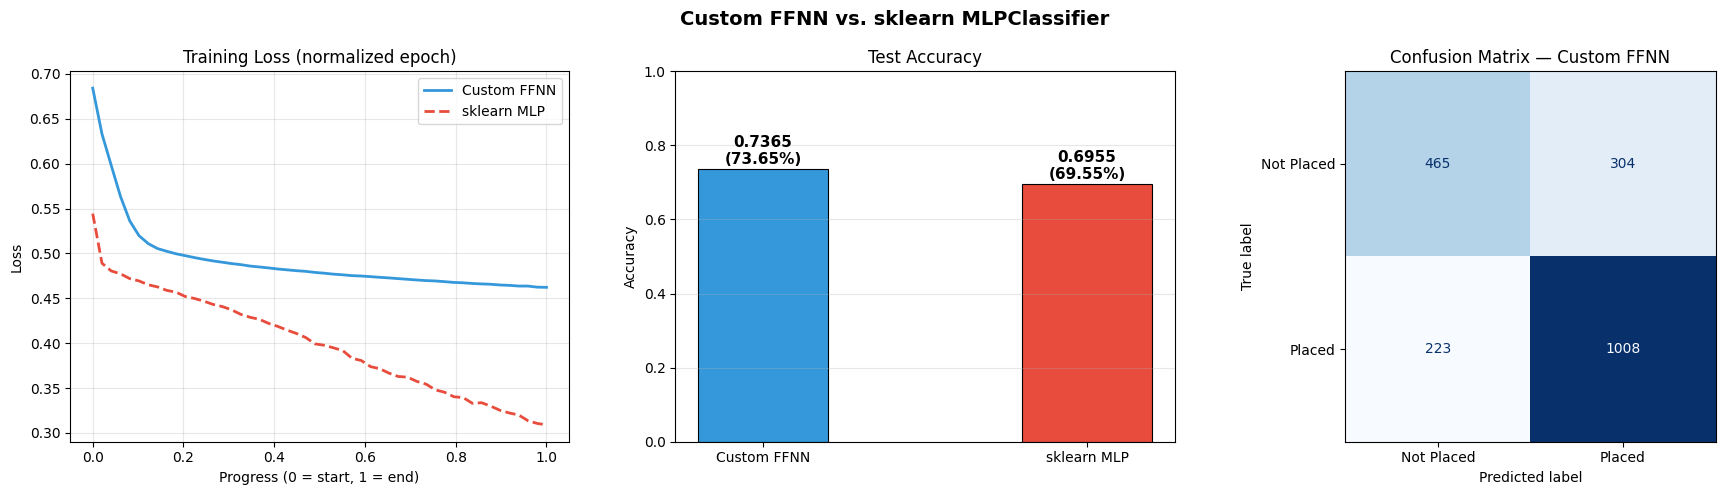


Model                       Test Accuracy
------------------------------------------
Custom FFNN                        0.7365  (73.65%)
sklearn MLPClassifier              0.6955  (69.55%)

Selisih (Custom − sklearn)  +      0.0410  (+4.10%)


In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# training loss curve 
custom_losses = m_custom.history["train_loss"]
sklearn_losses = mlp.loss_curve_

# normalkan ke jumlah epoch yg sama buat ngebanding-bandingin tren
ep_custom  = np.linspace(0, 1, len(custom_losses))
ep_sklearn = np.linspace(0, 1, len(sklearn_losses))

axes[0].plot(ep_custom,  custom_losses,  label="Custom FFNN",  linewidth=2,   color="#3498db")
axes[0].plot(ep_sklearn, sklearn_losses, label="sklearn MLP",  linewidth=2,   color="#e74c3c", linestyle="--")
axes[0].set_title("Training Loss (normalized epoch)")
axes[0].set_xlabel("Progress (0 = start, 1 = end)")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# bar chart test accuracy
model_names = ["Custom FFNN", "sklearn MLP"]
accs = [acc_custom, acc_sklearn]
bar_colors = ["#3498db", "#e74c3c"]
bars = axes[1].bar(model_names, accs, color=bar_colors, width=0.4, edgecolor="black", linewidth=0.8)
for bar, acc in zip(bars, accs):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{acc:.4f}\n({acc*100:.2f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )
axes[1].set_ylim(0, 1.0)
axes[1].set_title("Test Accuracy")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, axis="y", alpha=0.3)

# confusion matrix custom
y_pred_custom_cls = (m_custom.predict(X_test) >= 0.5).astype(int).ravel()
cm_custom = confusion_matrix(y_test.ravel(), y_pred_custom_cls)
disp = ConfusionMatrixDisplay(cm_custom, display_labels=["Not Placed", "Placed"])
disp.plot(ax=axes[2], colorbar=False, cmap="Blues")
axes[2].set_title("Confusion Matrix — Custom FFNN")

plt.suptitle("Custom FFNN vs. sklearn MLPClassifier", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n{'Model':<26} {'Test Accuracy':>14}")
print("-" * 42)
print(f"{'Custom FFNN':<26} {acc_custom:>14.4f}  ({acc_custom*100:.2f}%)")
print(f"{'sklearn MLPClassifier':<26} {acc_sklearn:>14.4f}  ({acc_sklearn*100:.2f}%)")
diff = acc_custom - acc_sklearn
sign = "+" if diff >= 0 else ""
print(f"\nSelisih (Custom − sklearn) {sign:>2}{diff:>12.4f}  ({sign}{diff*100:.2f}%)")


## 15. Perbandingan Konvergensi: SGD vs Adam

Analisis kecepatan konvergensi dua optimizer pada arsitektur yang sama:

| Optimizer | Learning Rate | Keterangan |
|-----------|:---:|---|
| SGD       | 0.01  | Gradient descent standar |
| Adam      | 0.001 | Adaptive moment estimation |

**Arsitektur tetap:** `Dense(64, relu) → Dense(32, relu) → Dense(1, sigmoid)`  
Epochs: 100  
Batch: 32

Metrik yang dibandingkan:
- Kurva train loss & val loss per epoch
- Epoch pertama kali val loss turun di bawah threshold (kecepatan konvergensi)
- Test accuracy akhir


In [31]:
OPTIMIZER_CONFIGS = {
    "SGD  (lr=0.01)":  {"optimizer": "sgd",  "learning_rate": 0.01},
    "Adam (lr=0.001)": {"optimizer": "adam", "learning_rate": 0.001},
}

conv_results = {}

for label, cfg in OPTIMIZER_CONFIGS.items():
    print(f"Training {label} ...", end=" ", flush=True)
    m = Model()
    m.add(Dense(units=64, activation="relu",    init="he"))
    m.add(Dense(units=32, activation="relu",    init="he"))
    m.add(Dense(units=1,  activation="sigmoid", init="xavier"))
    m.compile(loss="binary_crossentropy", **cfg)
    hist = m.fit(
        X_train, y_train,
        epochs=50, batch_size=32,
        validation_data=(X_test, y_test),
        verbose=0, shuffle=True,
    )
    _, acc = m.evaluate(X_test, y_test)
    conv_results[label] = {"history": hist, "acc": acc}
    print(f"test acc = {acc:.4f}")


Training SGD  (lr=0.01) ... test acc = 0.7460
Training Adam (lr=0.001) ... test acc = 0.7030


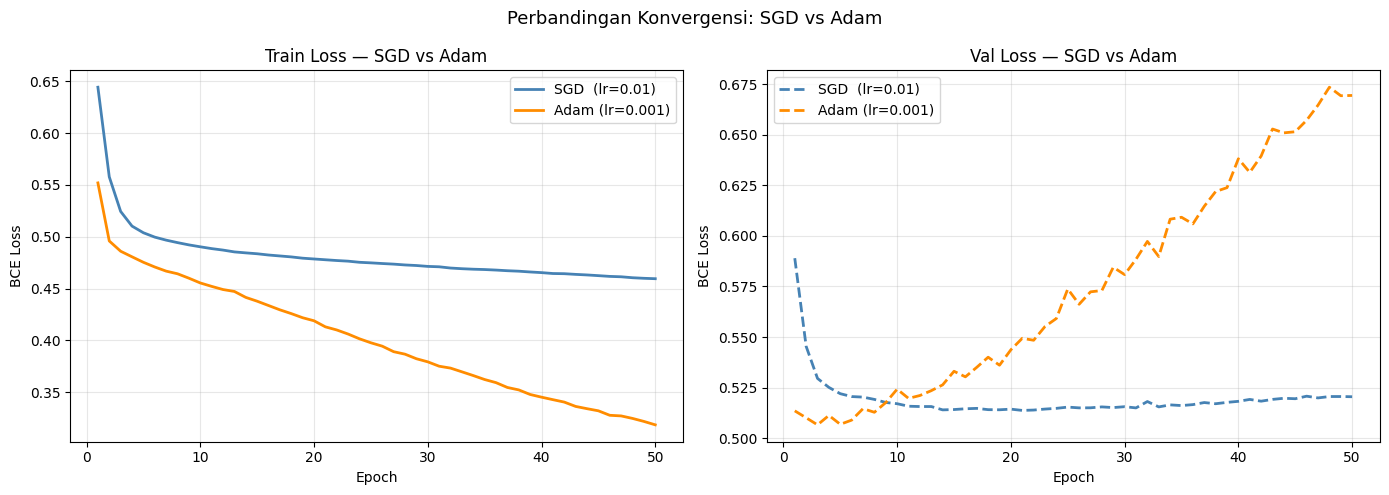

Epoch pertama val_loss < 0.5:
  SGD  (lr=0.01)        : epoch tidak tercapai
  Adam (lr=0.001)       : epoch tidak tercapai

Optimizer                Test Acc   Final Val Loss
----------------------------------------------------
SGD  (lr=0.01)             0.7460           0.5205
Adam (lr=0.001)            0.7030           0.6694


In [32]:
# Kurva loss 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["steelblue", "darkorange"]

for (label, res), color in zip(conv_results.items(), colors):
    ep = range(1, len(res["history"]["train_loss"]) + 1)
    axes[0].plot(ep, res["history"]["train_loss"], label=label, color=color, linewidth=2)
    axes[1].plot(ep, res["history"]["val_loss"],   label=label, color=color, linewidth=2, linestyle="--")

axes[0].set_title("Train Loss — SGD vs Adam")
axes[1].set_title("Val Loss — SGD vs Adam")
for ax in axes:
    ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Perbandingan Konvergensi: SGD vs Adam", fontsize=13)
plt.tight_layout()
plt.show()

# Kecepatan konvergensi: epoch pertama val_loss < threshold
THRESHOLD = 0.50
print(f"Epoch pertama val_loss < {THRESHOLD}:")
for label, res in conv_results.items():
    val_losses = res["history"]["val_loss"]
    epochs_below = [i+1 for i, v in enumerate(val_losses) if v < THRESHOLD]
    first = epochs_below[0] if epochs_below else "tidak tercapai"
    print(f"  {label:<22}: epoch {first}")

# Tabel akurasi akhir
print(f"\n{'Optimizer':<22} {'Test Acc':>10}  {'Final Val Loss':>15}")
print("-" * 52)
for label, res in conv_results.items():
    final_val = res["history"]["val_loss"][-1]
    print(f"{label:<22} {res['acc']:>10.4f}  {final_val:>15.4f}")


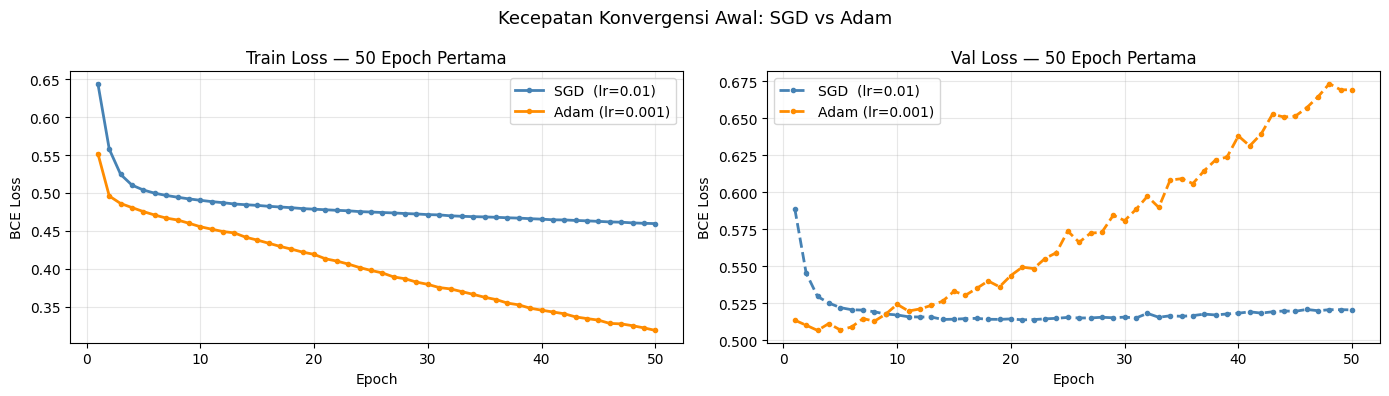

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for (label, res), color in zip(conv_results.items(), colors):
    axes[0].plot(range(1, 50+1), res["history"]["train_loss"][:50],
                 label=label, color=color, linewidth=2, marker="o", markersize=3)
    axes[1].plot(range(1, 50+1), res["history"]["val_loss"][:50],
                 label=label, color=color, linewidth=2, marker="o", markersize=3, linestyle="--")

axes[0].set_title(f"Train Loss — {50} Epoch Pertama")
axes[1].set_title(f"Val Loss — {50} Epoch Pertama")
for ax in axes:
    ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Kecepatan Konvergensi Awal: SGD vs Adam", fontsize=13)
plt.tight_layout()
plt.show()


## 16. Pengaruh Normalisasi: Tanpa vs. RMSNorm

**RMSNorm** untuk normalisasi menggunakan Root Mean Square per sampel, kemudian menskalakan hasilnya dengan parameter yang dapat dipelajari (γ):

$$\text{RMSNorm}(x) = \frac{x}{\text{RMS}(x)} \cdot \gamma, \quad \text{RMS}(x) = \sqrt{\frac{1}{D}\sum_{i=1}^{D} x_i^2 + \varepsilon}$$

RMSNorm dilakukan setelah setiap hidden layer (sebelum aktivasi lapisan berikutnya):

| Model | Arsitektur |
|-------|-----------|
| Tanpa Norm | `Dense(64, relu) → Dense(32, relu) → Dense(1, sigmoid)` |
| Dengan RMSNorm | `Dense(64, relu) → RMSNorm → Dense(32, relu) → RMSNorm → Dense(1, sigmoid)` |

**Hyperparameter:**  
learning rate = 0.01  
SGD  
epochs = 100  
batch = 32

Perbandingan:
- Kurva training loss & validation loss per epoch
- Test accuracy & final val loss
- Distribusi bobot & gradien semua layer


In [34]:
from layer import RMSNorm

NORM_CONFIGS = {
    "Tanpa Norm": False,
    "Dengan RMSNorm": True,
}

EPOCHS_NORM = 100

norm_results = {}
norm_models  = {}

for label, use_norm in NORM_CONFIGS.items():
    print(f"Training {label} ...", end=" ", flush=True)
    m = Model()
    m.add(Dense(units=64, activation="relu", init="he"))
    if use_norm:
        m.add(RMSNorm())
    m.add(Dense(units=32, activation="relu", init="he"))
    if use_norm:
        m.add(RMSNorm())
    m.add(Dense(units=1, activation="sigmoid", init="xavier"))
    m.compile(loss="binary_crossentropy", learning_rate=0.01)
    hist = m.fit(
        X_train, y_train,
        epochs=EPOCHS_NORM, batch_size=32,
        validation_data=(X_test, y_test),
        verbose=0, shuffle=True,
    )
    _, acc = m.evaluate(X_test, y_test)
    norm_results[label] = {"history": hist, "acc": acc}
    norm_models[label]  = m
    print(f"test acc = {acc:.4f}")


Training Tanpa Norm ... test acc = 0.7420
Training Dengan RMSNorm ... test acc = 0.7285


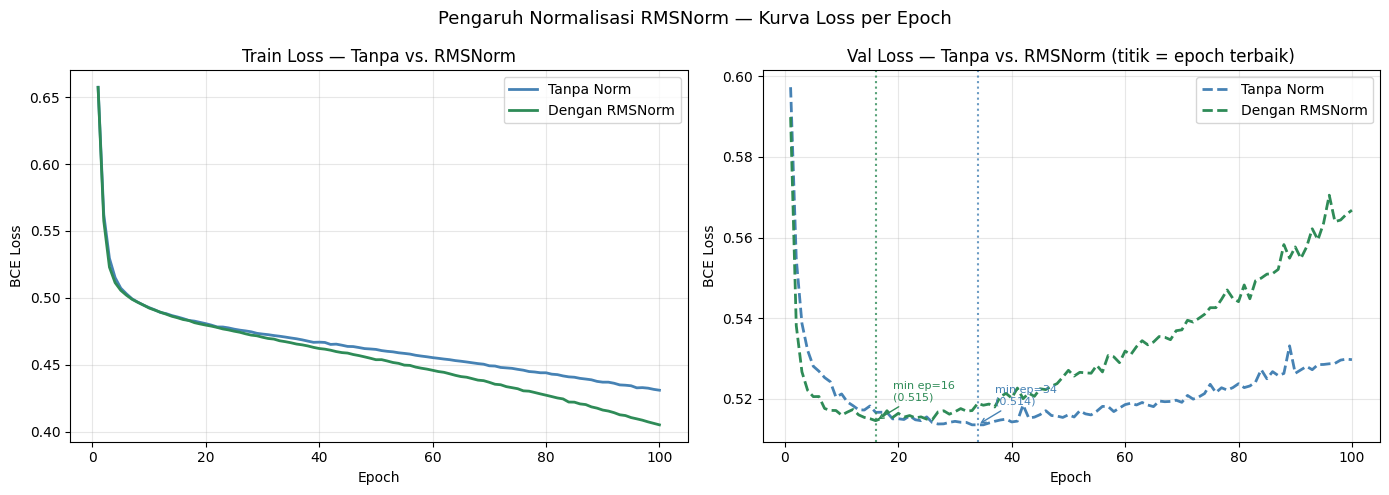


Model                    Test Acc   Best Epoch   Min Val Loss   Final Val Loss
----------------------------------------------------------------------------
Tanpa Norm                 0.7420           34         0.5135           0.5297
Dengan RMSNorm             0.7285           16         0.5145           0.5668


In [35]:
# Kurva loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_norm = ["steelblue", "seagreen"]

for (label, res), color in zip(norm_results.items(), colors_norm):
    ep = range(1, len(res["history"]["train_loss"]) + 1)
    axes[0].plot(ep, res["history"]["train_loss"], label=label, color=color, linewidth=2)
    axes[1].plot(ep, res["history"]["val_loss"],   label=label, color=color, linewidth=2, linestyle="--")

    val_losses = res["history"]["val_loss"]
    best_ep  = int(np.argmin(val_losses)) + 1
    best_val = val_losses[best_ep - 1]
    axes[1].axvline(best_ep, color=color, linestyle=":", linewidth=1.5, alpha=0.8)
    axes[1].annotate(
        f"min ep={best_ep}\n({best_val:.3f})",
        xy=(best_ep, best_val),
        xytext=(best_ep + 3, best_val + 0.005),
        fontsize=8, color=color,
        arrowprops=dict(arrowstyle="->", color=color, lw=1),
    )

axes[0].set_title("Train Loss — Tanpa vs. RMSNorm")
axes[1].set_title("Val Loss — Tanpa vs. RMSNorm (titik = epoch terbaik)")
for ax in axes:
    ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Pengaruh Normalisasi RMSNorm — Kurva Loss per Epoch", fontsize=13)
plt.tight_layout()
plt.show()

# Tabel hasil akhir
print(f"\n{'Model':<22} {'Test Acc':>10}  {'Best Epoch':>11}  {'Min Val Loss':>13}  {'Final Val Loss':>15}")
print("-" * 76)
for label, res in norm_results.items():
    val_losses = res["history"]["val_loss"]
    best_ep  = int(np.argmin(val_losses)) + 1
    best_val = val_losses[best_ep - 1]
    final_val = val_losses[-1]
    print(f"{label:<22} {res['acc']:>10.4f}  {best_ep:>11}  {best_val:>13.4f}  {final_val:>15.4f}")


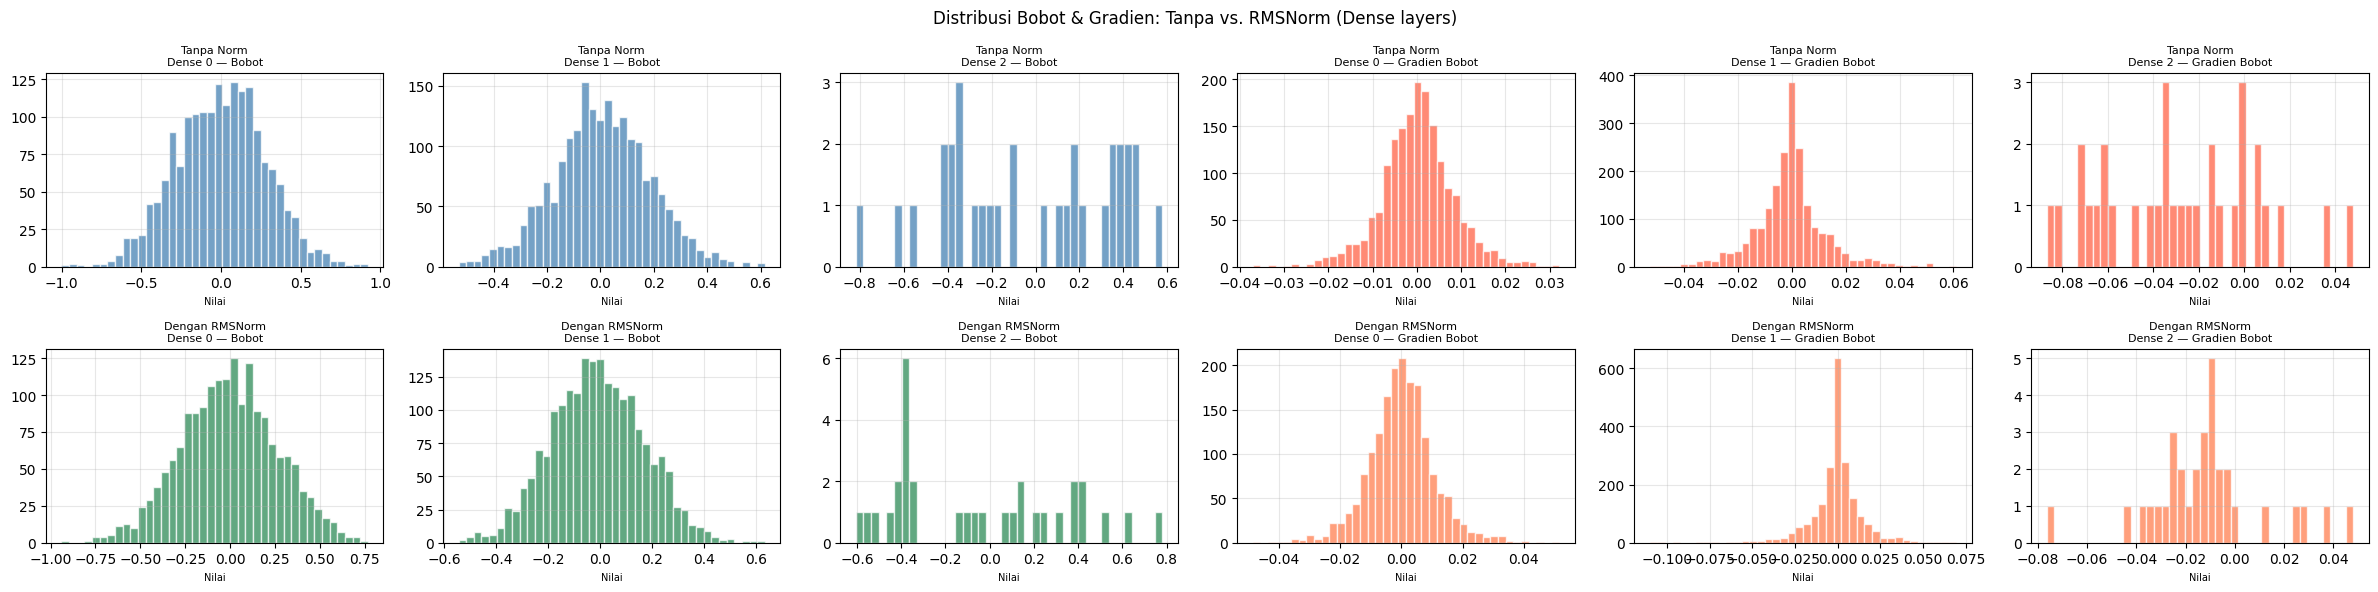

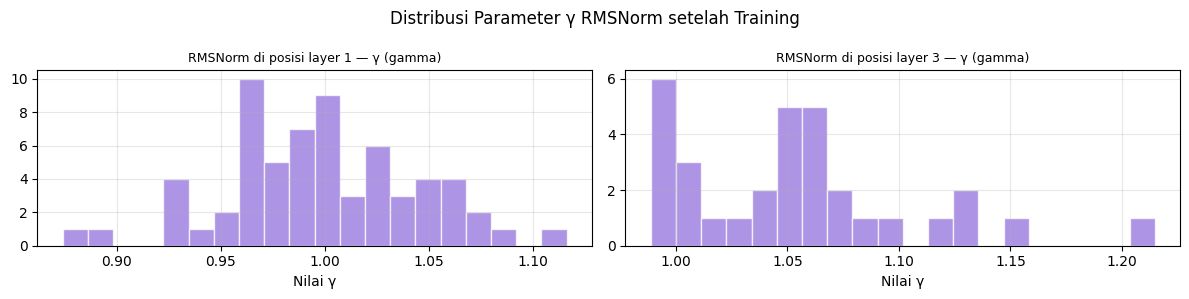

In [36]:
# Distribusi bobot & gradien
X_batch64 = X_train[:64]
y_batch64  = y_train[:64]

names_norm = list(norm_models.keys())
n_models   = len(names_norm)
N_DENSE    = 3 

colors_w2 = ["steelblue", "seagreen"]
colors_g2 = ["tomato",    "coral"]

fig, axes = plt.subplots(n_models, N_DENSE * 2, figsize=(4 * N_DENSE * 2, 3 * n_models))
if n_models == 1:
    axes = axes.reshape(1, -1)

for row, name in enumerate(names_norm):
    m = norm_models[name]
    out = m.forward(X_batch64)
    m.backward(out, y_batch64)

    dense_layers = [l for l in m.layers if isinstance(l, Dense)]

    for li, layer in enumerate(dense_layers):
        ax_w = axes[row, li]
        if layer.W is not None:
            ax_w.hist(layer.W.flatten(), bins=40, alpha=0.75,
                      color=colors_w2[row], edgecolor="white")
        ax_w.set_title(f"{name}\nDense {li} — Bobot", fontsize=8)
        ax_w.set_xlabel("Nilai", fontsize=7)
        ax_w.grid(True, alpha=0.3)

        ax_g = axes[row, N_DENSE + li]
        if layer._dW is not None:
            ax_g.hist(layer._dW.flatten(), bins=40, alpha=0.75,
                      color=colors_g2[row], edgecolor="white")
        ax_g.set_title(f"{name}\nDense {li} — Gradien Bobot", fontsize=8)
        ax_g.set_xlabel("Nilai", fontsize=7)
        ax_g.grid(True, alpha=0.3)

plt.suptitle("Distribusi Bobot & Gradien: Tanpa vs. RMSNorm (Dense layers)", fontsize=12)
plt.tight_layout()
plt.show()

# Distribusi gamma RMSNorm 
norm_model = norm_models["Dengan RMSNorm"]
rms_layers = [(i, l) for i, l in enumerate(norm_model.layers) if isinstance(l, RMSNorm)]

if rms_layers:
    fig, axes = plt.subplots(1, len(rms_layers), figsize=(6 * len(rms_layers), 3))
    if len(rms_layers) == 1:
        axes = [axes]
    for ax, (idx, layer) in zip(axes, rms_layers):
        ax.hist(layer.gamma.flatten(), bins=20, color="mediumpurple", alpha=0.75, edgecolor="white")
        ax.set_title(f"RMSNorm di posisi layer {idx} — γ (gamma)", fontsize=9)
        ax.set_xlabel("Nilai γ"); ax.grid(True, alpha=0.3)
    plt.suptitle("Distribusi Parameter γ RMSNorm setelah Training", fontsize=12)
    plt.tight_layout()
    plt.show()


## 17. FFNN dengan Automatic Differentiation

**Automatic differentiation (autograd)** menghilangkan kebutuhan untuk menulis method backward secara manual dan menggantinya sehingga
1. Setiap operasi pada `Tensor` membangun computation graph secara otomatis
2. Memanggil `loss.backward()` akan menghitung semua gradien sekaligus via chain rule
3. Layer tidak perlu method `backward()` — cukup forward saja

### Implementasi

Autograd terintegrasi langsung ke `Model`, `Dense`, `RMSNorm`, dan semua loss function yang sudah ada. Untuk mengaktifkan, dapat diaktifkan dengan menambahkan `autograd=True` pada method `compile()`:

In [37]:
ag_model = Model()
ag_model.add(Dense(64, activation="relu"))
ag_model.add(Dense(32, activation="relu"))
ag_model.add(Dense(1, activation="sigmoid"))
ag_model.compile(
    loss="binary_crossentropy", optimizer="sgd",
    learning_rate=0.01, autograd=True  # untuk mengaktifkan autograd
)

ag_model.summary(input_shape=X_train.shape[1])
print(f"Layer autograd flags: {[l.autograd for l in ag_model.layers]}")

ag_history = ag_model.fit(
    X_train, y_train,
    epochs=50, batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0,
)

manual_model_cmp = Model()
manual_model_cmp.add(Dense(64, activation="relu"))
manual_model_cmp.add(Dense(32, activation="relu"))
manual_model_cmp.add(Dense(1, activation="sigmoid"))
manual_model_cmp.compile(
    loss="binary_crossentropy", optimizer="sgd",
    learning_rate=0.01  # tanpa autograd (default)
)

manual_history_cmp = manual_model_cmp.fit(
    X_train, y_train,
    epochs=50, batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0,
)

Model Summary
Layer                Output Shape         Param #        
----------------------------------------------------------------------
Dense_0              (None, 64)           1,856          
Dense_1              (None, 32)           2,080          
Dense_2              (None, 1)            33             
Total params: 3,969
Layer autograd flags: [True, True, True]


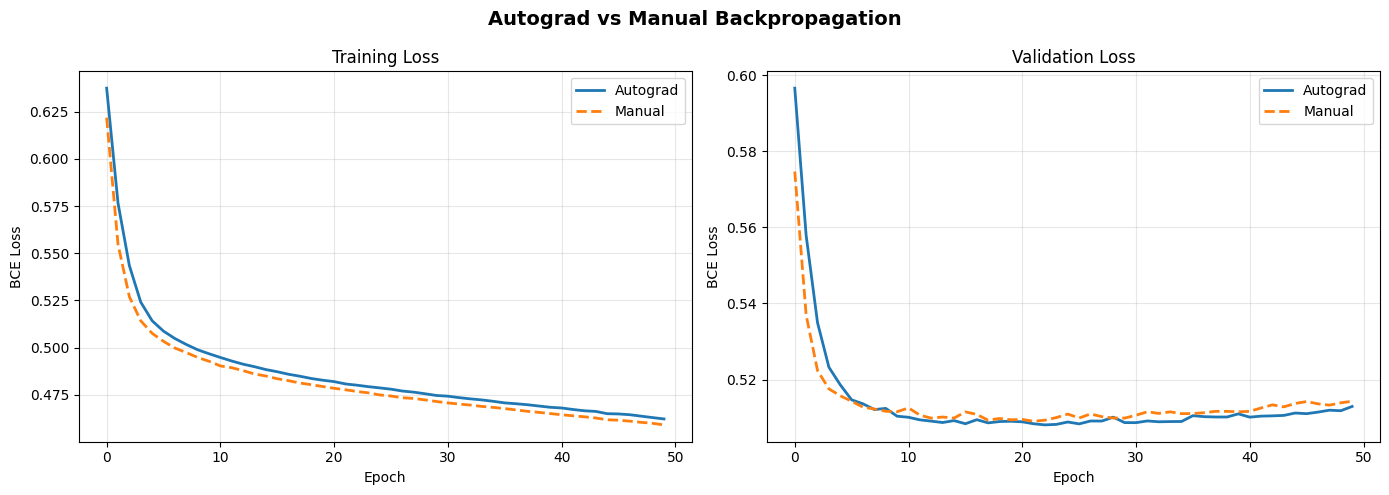


Model                  Train Loss     Val Loss   Test Acc
--------------------------------------------------------
Autograd                   0.4622       0.5129     0.7430
Manual                     0.4591       0.5143     0.7555


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ag_history["train_loss"], label="Autograd", linewidth=2)
axes[0].plot(manual_history_cmp["train_loss"], label="Manual", linewidth=2, linestyle="--")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ag_history["val_loss"], label="Autograd", linewidth=2)
axes[1].plot(manual_history_cmp["val_loss"], label="Manual", linewidth=2, linestyle="--")
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("BCE Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Autograd vs Manual Backpropagation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Tabel akurasi
ag_pred = (ag_model.predict(X_test) >= 0.5).astype(int).flatten()
manual_pred = (manual_model_cmp.predict(X_test) >= 0.5).astype(int).flatten()

ag_acc = np.mean(ag_pred == y_test.flatten())
manual_acc = np.mean(manual_pred == y_test.flatten())

print(f"\n{'Model':<20} {'Train Loss':>12} {'Val Loss':>12} {'Test Acc':>10}")
print("-" * 56)
print(f"{'Autograd':<20} {ag_history['train_loss'][-1]:>12.4f} {ag_history['val_loss'][-1]:>12.4f} {ag_acc:>10.4f}")
print(f"{'Manual':<20} {manual_history_cmp['train_loss'][-1]:>12.4f} {manual_history_cmp['val_loss'][-1]:>12.4f} {manual_acc:>10.4f}")

## 18. Pengaruh Inisialisasi Bobot

Inisialisasi bobot menentukan titik awal optimisasi dan berdampak besar pada kecepatan konvergensi maupun kualitas solusi akhir. Eksperimen ini membandingkan beberapa metode inisialisasi yang tersedia:

| Metode | Deskripsi |
|---|---|
| `zeros` | Semua bobot diinisialisasi 0 — simetri, gradien identik, tidak belajar |
| `uniform` | Sampel seragam dari `[-0.1, 0.1]` |
| `normal` | Sampel normal $\mathcal{N}(0, 0.01)$ |
| `xavier` | $\mathcal{N}(0, \sqrt{1/\text{fan\_in}})$ — cocok untuk linear/sigmoid/tanh |
| `he` | $\mathcal{N}(0, \sqrt{2/\text{fan\_in}})$ — cocok untuk ReLU |
| `auto` | Pilih he untuk ReLU, xavier untuk aktivasi lain |


In [39]:
INIT_CONFIGS = {
    "zeros":   {"init": "zeros"},
    "uniform": {"init": "uniform"},
    "normal":  {"init": "normal"},
    "xavier":  {"init": "xavier"},
    "he":      {"init": "he"},
    "auto":    {"init": "auto"},
}

EPOCHS_INIT = 100
init_results = {}

for name, cfg in INIT_CONFIGS.items():
    m_init = Model()
    m_init.add(Dense(64, activation="relu", **cfg))
    m_init.add(Dense(32, activation="relu", **cfg))
    m_init.add(Dense(1,  activation="sigmoid", **cfg))
    m_init.compile(loss="binary_crossentropy", optimizer="adam", learning_rate=0.001)

    h = m_init.fit(
        X_train, y_train,
        epochs=EPOCHS_INIT, batch_size=32,
        validation_data=(X_test, y_test),
        verbose=0,
    )
    _, acc = m_init.evaluate(X_test, y_test)
    init_results[name] = {"history": h, "acc": acc}
    print(f"{name:<10} | train_loss={h['train_loss'][-1]:.4f} | val_loss={h['val_loss'][-1]:.4f} | test_acc={acc:.4f}")


zeros      | train_loss=0.6664 | val_loss=0.6662 | test_acc=0.6155
uniform    | train_loss=0.2869 | val_loss=0.8088 | test_acc=0.7040
normal     | train_loss=0.3601 | val_loss=0.6654 | test_acc=0.7110
xavier     | train_loss=0.2275 | val_loss=0.9529 | test_acc=0.6890
he         | train_loss=0.2239 | val_loss=0.9874 | test_acc=0.6805
auto       | train_loss=0.2229 | val_loss=1.0277 | test_acc=0.6825


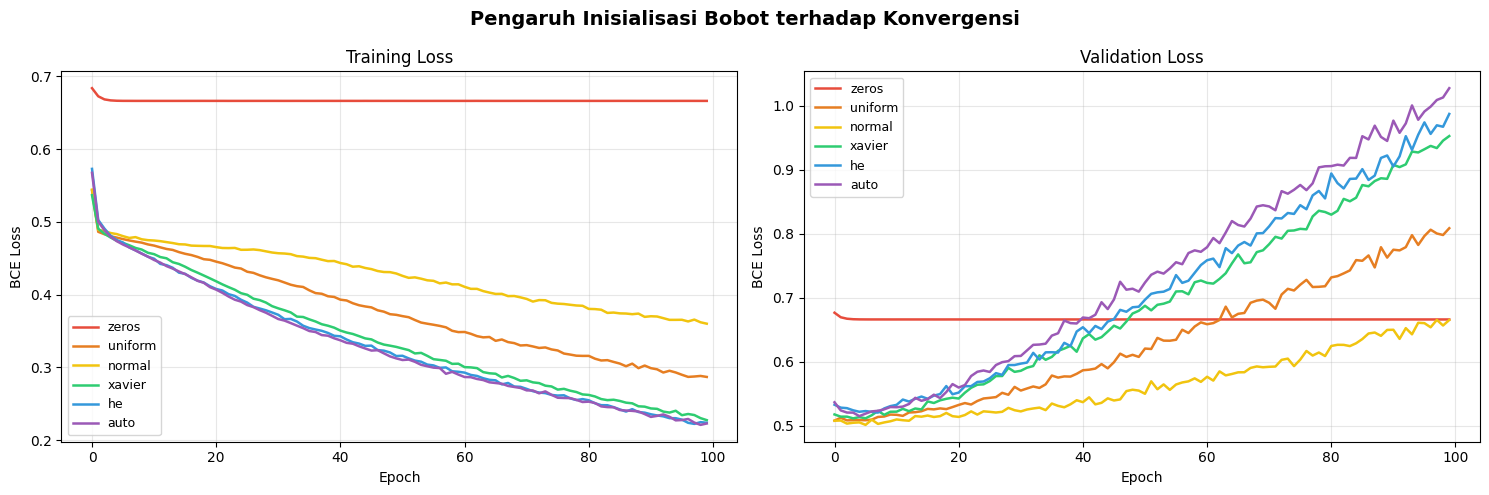


Init         Train Loss     Val Loss   Test Acc
----------------------------------------------
zeros            0.6664       0.6662     0.6155
uniform          0.2869       0.8088     0.7040
normal           0.3601       0.6654     0.7110
xavier           0.2275       0.9529     0.6890
he               0.2239       0.9874     0.6805
auto             0.2229       1.0277     0.6825


In [40]:
colors_init = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#3498db", "#9b59b6"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for (name, res), color in zip(init_results.items(), colors_init):
    axes[0].plot(res["history"]["train_loss"], label=name, linewidth=1.8, color=color)
    axes[1].plot(res["history"]["val_loss"],   label=name, linewidth=1.8, color=color)

for ax, title in zip(axes, ["Training Loss", "Validation Loss"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Pengaruh Inisialisasi Bobot terhadap Konvergensi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ringkasan akurasi
print(f"\n{'Init':<10} {'Train Loss':>12} {'Val Loss':>12} {'Test Acc':>10}")
print("-" * 46)
for name, res in init_results.items():
    tl = res["history"]["train_loss"][-1]
    vl = res["history"]["val_loss"][-1]
    print(f"{name:<10} {tl:>12.4f} {vl:>12.4f} {res['acc']:>10.4f}")
